<a href="https://colab.research.google.com/github/RiccardoDL7/AI-For-Finance---Corporate-Bankruptcy-Prediction/blob/main/Copy_of_notebook_definitivo_rich_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Methods and Application of Machine Learning: Group Project
---

## Group component:
Alberto Macovei

Pasqualexia Ambrosini

Riccardo De Leonardis



---



# Education, HIV, and Early Fertility: Experimental Evidence from Kenya
*by Esther Duflo, Pascaline Dupas, and Michael Kremer (American Economic Review, 2015)*

Our project builds upon the experiment conducted by Esther Duflo, Pascaline Dupas, and Michael Kremer in conjunction with the Kenya Ministry of Education, Kenya National AIDS Control Council, and the non-profit ICS Africa, which evaluates the impacts of education and health interventions on adolescent behavior in rural Western Kenya.

The baseline study leverages a cluster-randomized controlled trial (RCT) involving 328 primary schools.

The experiment was engineered to compare two public policy effect the  desgin, in particular, for fighting high rates of school dropout, early fertility, and sexually transmitted infections (STIs/HIV):

1. **School Subsidy, $D_S$:** Lowering the direct costs of education by providing free school uniforms for two years to students who had not yet completed primary school. This acts as economic help and an incentive to stay enrolled.
2. **HIV Curriculum, $D_H$:** Training teachers to deliver Kenya’s national HIV/AIDS prevention curriculum, which heavily emphasized abstinence until marriage and highlighted the severe risks of infection.
3. **The Joint Program ($D_{SH}$):** Deploying both the programs simultaneously to exploit potential programmatic cross-effects.

This could be summarized in :

### 2x2 Factorial Experimental Design Matrix


| | **Factor 2: HIV Curriculum = NO** | **Factor 2: HIV Curriculum = YES** |
| :--- | :--- | :--- |
| **Factor 1: Uniforms = NO** | **Pure Control** <br><br> *(No Uniforms, No HIV Curriculum)* | **HIV curriculum only ($D_H$)** <br><br> *(No Uniforms, Yes HIV Curriculum)* |
| **Factor 1: Uniforms = YES** | **Just Subsidy ($D_S$)** <br><br> *(Yes Uniforms, No HIV Curriculum)* | **Joint Program ($D_{SH}$)** <br><br> *(Yes Uniforms, Yes HIV Curriculum)* |






# 0. Executive Summary: Background Paper and Principal Empirical Findings

### 0.1 Institutional Context and Experimental Setup
This notebook builds upon the landmark field experiment conducted by Esther Duflo, Pascaline Dupas, and Michael Kremer (American Economic Review, 2015), which evaluates the long-term impacts of education and health interventions on adolescent behavior in rural Kenya. The baseline study leverages a cluster-randomized controlled trial (RCT) involving 328 primary schools, structured under a pristine 2x2 factorial design. The experiment was engineered to pit two competing public policy paradigms against each other to combat high rates of school dropout, early fertility, and sexually transmitted infections (STIs):

1. **The Economic Paradigm (School Subsidy, $D_S$):** Lowering the direct costs of education by providing free school uniforms for two years to students who had not yet completed primary school. This acts as a pure wealth shock and an incentive to stay enrolled.
2. **The Informational Paradigm (HIV Curriculum, $D_H$):** Training teachers to deliver Kenya’s national HIV/AIDS prevention curriculum, which heavily emphasized abstinence until marriage and highlighted the severe risks of infection.
3. **The Joint Program ($D_{SH}$):** Deploying both the uniforms and the curriculum simultaneously to exploit potential programmatic cross-effects.
4. **The Control Group:** Operating under the standard state framework with no additional subsidies or specialized teacher training.

### 0.2 Theoretical Mechanics: The "Health Paradox" and the Substitution Effect
The core economic contribution of the baseline paper is the deconstruction of the single-factor behavioral model of youth risk. Standard policy frameworks historically assumed that education acts as a universal, linear "social vaccine"—meaning that simply keeping adolescents in school automatically reduces risky sexual behavior and health risks by increasing the cost-opportunity of their time.

Duflo et al. (2015) introduce a **two-factor behavioral model** that splits relationships into two distinct categories with asymmetric risk profiles:
* **Committed/Marital Relationships:** Feature low perceived risks of STIs, lower social stigma for fertility, but high alternative costs if a girl wishes to continue her education.
* **Casual/Occasional Relationships:** Feature high background infection risks, high social stigma for out-of-wedlock pregnancy, but a lower immediate institutional barrier to temporary school attendance.

When the fee subsidy ($D_S$) is introduced, it drastically increases the returns to staying in school. To maintain eligibility and complete their education, girls delay entering stable matrimonial unions. Consequently, **the subsidy strongly reduces early marriage and marital pregnancies.** However, this triggers a powerful behavioral **Substitution Effect**: by staying in school longer, girls are exposed to wider social networks and peer environments outside parental supervision. To satisfy relational utilities without marrying, they substitute away from committed marital unions toward casual, uncommitted relationships. Because casual networks carry a significantly higher background prevalence of STIs, **schooling alone fails to reduce biological infection rates.** This phenomenon constitutes the **"Health Paradox"** of education: economic incentives alter the composition of relationships rather than eradicating risk, rendering pure school retention an insufficient health intervention when delivered in isolation.

### 0.3 Summary of Original Empirical Findings
The long-term (7-year) Intention-to-Treat (ITT) estimates reported in the original paper establish several stark empirical regularities, which our Causal ML pipeline aims to evaluate under regularized and non-parametric bounds:

* **Educational Attainment:** The education subsidy ($D_S$) operated as a highly effective driver of human capital retention. It significantly reduced female primary school dropout and increased overall years of school completed. Conversely, the HIV curriculum ($D_H$) had an economically and statistically negligible effect on school enrollment margins.
* **The Fertility Multi-Biases:** When examining fertility, the subsidy ($D_S$) achieved a massive and robust reduction in **marital pregnancies**. However, consistent with the substitution hypothesis, it caused a net *increase* (though often precisely estimated near zero or marginally positive) in **unwed pregnancies**. The informational curriculum ($D_H$) demonstrated no independent capacity to lower aggregate pregnancy rates.
* **Epidemiological Complementarity:** The biological test for Herpes Simplex Virus 2 (`Y_HSV2`) revealed that neither the uniform subsidy ($D_S$) nor the HIV curriculum ($D_H$) reduced infection rates when administered independently. However, the **joint program ($D_{SH}$) generated a substantial, statistically significant reduction in HSV-2 prevalence.** ### 0.4 Policy Implications and Modular Independence
The overarching lesson for policy design is one of strategic complementarity. The school subsidy acts as the necessary **vehicle** (keeping girls inside an institutional environment and delaying structural marriage), while the HIV curriculum acts as the **driver** (providing the informational capital needed to navigate newly formed casual peer networks safely via protection or abstinence).

Furthermore, the paper's original additivity checks suggested that on educational margins, the programs behave as modular, independent units—implying that public budgets can deploy them conditionally based on administrative capacity without triggering negative structural crowding-out on school completion rates.

# 1. Introduction: Research Objectives, Causal Chain, and "Duflo's Puzzle"

### 1.1 Aims and Economic Rationale
The primary objective of this empirical study is to estimate and interpret the long-term causal impact (at the 7-year follow-up horizon in 2007) of macro-educational and health interventions targeting adolescents in rural Kenya. Based on the 2x2 factorial randomized controlled trial (RCT) designed by Duflo, Dupas, and Kremer (AER, 2015), our pipeline simultaneously evaluates all three active treatment arms: a material economic subsidy (free school uniforms, $D_S$), a pure informational intervention (teacher training on the national HIV abstinence curriculum, $D_H$), and the combined joint program ($D_{SH}$).

Our analysis maps a **multi-stage structural causal chain** to verify whether lowering the direct costs of schooling acts as a sustainable "social vaccine." We trace whether this initial economic shock permanently alters educational attachment (Cumulative Dropout by 2007, `Y_Drop`; Years of School Completed, `Y_Grades_Comp`) and whether such behavioral retention translates into protective impacts on fertility (`Y_Preg_7yr`) and biological reproductive health (Herpes Simplex Virus 2 infection, `Y_HSV2`). HSV-2 is leveraged as an objective, biomarker-backed proxy for unprotected sexual exposure, inherently immune to the self-reporting and social desirability biases that contaminate questionnaire data.

We extend the original paper's classical linear framework by deploying **Causal Machine Learning** to resolve three systemic identification challenges: non-random panel attrition over 7 years, functional form misspecification of control variables, and multiple-hypothesis testing bias ($p$-hacking) in subgroup analysis. Finally, by systematically integrating the male subsample, we provide a behavioral counter-verification to isolate sex-specific fertility pathways from universal wealth effects, directly cracking the macro-policy question known as "Duflo's Puzzle."

### 1.2 Methodological Objectives
To execute this causal framework, the notebook implements five sequential analytical stages:
1. **Dual-Space Feature Engineering:** Construct two distinct covariate matrices (`X_Tree` and `X_Lasso`) to optimize the functional performance of tree-based and regularized linear estimators respectively.
2. **Attrition Compensation via Inverse Probability Weighting (IPW):** Model panel observability propensities using a non-parametric `RandomForestClassifier` to synthetically reconstruct the unconfounded baseline population of 2003.
3. **Orthogonalized ATE Estimation via Multi-Valued Double ML:** Deploy a partially linear Double ML model (`LinearDML`) to isolate population-average treatment effects across all arms simultaneously, neutralizing regularization bias.
4. **Policy Additivity Verification via the Wald Test:** Perform structural linear restriction tests on the DML residuals to evaluate whether joint assignment suffers from sub-additive crowding out or exhibits synergistic complementarities.
5. **Non-Parametric CATE Mapping and BLP Validation:** Deploy an Interactive Regression Model (`DoubleMLIRM`) to extract individual doubly robust score vectors, feeding them into Causal Forests to map effect heterogeneity along structural axes (e.g., school size `schsize`, baseline academic quality `kcpe2003`), with strict validation via Chernozhukov's Best Linear Predictor (BLP) Omnibus test.

# Causal Analysis with Double Machine Learning
This notebook executes the complete analysis pipeline for Duflo's education and HIV experiment.
Every graph and output is generated in a separate cell to isolate the analysis steps.

In [ ]:
# 1. Installa le librerie mancanti su Colab
!pip install doubleml econml statsmodels

# 2. Collega il tuo Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.7/607.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.1/513.1 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0
Mounted at /content/drive


In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import warnings
from IPython.display import display, HTML
from statsmodels.tools.sm_exceptions import ValueWarning

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.simplefilter('ignore', ValueWarning)

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.linear_model import RidgeCV, LassoLarsIC, LogisticRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor, plot_tree

import doubleml as dml
import statsmodels.api as sm
import statsmodels.formula.api as smf
from econml.dml import LinearDML

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)

def get_clean_wls_table(ols_model, target_var):
    summary = ols_model.summary2().tables[1]
    return summary.loc[[target_var]]


## 1. Data Loading and Preparation

In [ ]:
base_path = '/content/drive/MyDrive/Duflo_Data'

student_df = pd.read_stata(os.path.join(base_path, 'studysample_allmerged.dta'), convert_categoricals=False)
school_df = pd.read_stata(os.path.join(base_path, 'school_info.dta'), convert_categoricals=False)


df = student_df.merge(school_df, on='schoolid', how='left', suffixes=('', '_sch'))

df['D_S'] = ((df['Utreat'] == 1) & (df['HIVtreat'] == 0)).astype(int)
df['D_H'] = ((df['Utreat'] == 0) & (df['HIVtreat'] == 1)).astype(int)
df['D_SH'] = ((df['Utreat'] == 1) & (df['HIVtreat'] == 1)).astype(int)
df['Control'] = ((df['Utreat'] == 0) & (df['HIVtreat'] == 0)).astype(int)

df['Y_Drop'] = pd.to_numeric(df['dropout07v2'], errors='coerce')
df['Y_Preg'] = pd.to_numeric(df['evpreg07v2'], errors='coerce')
df['Y_HSV2'] = pd.to_numeric(df['hsv2_positive'], errors='coerce')
df['Y_Preg_Marital_5yr'] = ((df['evpreg07v2'] == 1) & (df['evmar07v2'] == 1)).astype(float)
df.loc[df['evpreg07v2'].isna() | df['evmar07v2'].isna(), 'Y_Preg_Marital_5yr'] = np.nan
df['Y_Preg_Unwed_5yr'] = ((df['evpreg07v2'] == 1) & (df['evmar07v2'] == 0)).astype(float)
df.loc[df['evpreg07v2'].isna() | df['evmar07v2'].isna(), 'Y_Preg_Unwed_5yr'] = np.nan

df['Y_Drop_3yr'] = pd.to_numeric(df['dropout05v3'], errors='coerce')
df['Y_Preg_3yr'] = pd.to_numeric(df['evpreg05v3'], errors='coerce')
df['Y_Preg_Unwed_3yr'] = ((df['evpreg05v3'] == 1) & (df['evmar05v3'] == 0)).astype(float)
df.loc[df['evpreg05v3'].isna() | df['evmar05v3'].isna(), 'Y_Preg_Unwed_3yr'] = np.nan
df['Y_Preg_Marital_3yr'] = ((df['evpreg05v3'] == 1) & (df['evmar05v3'] == 1)).astype(float)
df.loc[df['evpreg05v3'].isna() | df['evmar05v3'].isna(), 'Y_Preg_Marital_3yr'] = np.nan

df['Y_Preg_7yr'] = ((df['Q_b6_139_given_birth'] == 1) | (df['Q_b6_161_pregnant'] == 1)).astype(float)
df.loc[df['LOG_surveyed'] != 1, 'Y_Preg_7yr'] = np.nan

df['Y_Preg_Marital_7yr'] = ((df['Y_Preg_7yr'] == 1) & (df['Q_b4_114_marital_status'].isin([1.0, 2.0, 3.0]))).astype(float)
df.loc[df['Y_Preg_7yr'].isna() | df['Q_b4_114_marital_status'].isna(), 'Y_Preg_Marital_7yr'] = np.nan
df['Y_Preg_Unwed_7yr'] = ((df['Y_Preg_7yr'] == 1) & (df['Q_b4_114_marital_status'] == 4.0)).astype(float)
df.loc[df['Y_Preg_7yr'].isna() | df['Q_b4_114_marital_status'].isna(), 'Y_Preg_Unwed_7yr'] = np.nan

_edu = df['Q_b1_12_edu_level'].copy()
_edu = _edu.replace('', np.nan).replace({'F1': '9', 'F2': '10', 'F3': '11', 'F4': '12'})
df['Y_Grades_Comp'] = pd.to_numeric(_edu, errors='coerce')
df['Y_Reached_8th'] = (df['Y_Grades_Comp'] > 7).astype(float)
df.loc[df['Y_Grades_Comp'].isna(), 'Y_Reached_8th'] = np.nan

df['female'] = (df['sex'] == 2).astype(int)

cols_to_impute = ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'total_2km', 'TOTteachers', 'meanage', 'situation', 'Nfemale']
for col in cols_to_impute:
    df[f'{col}_missing'] = df[col].isna().astype(int)

desc_vars = ['female', 'yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'Y_Drop', 'Y_Preg', 'Y_HSV2']
print("Descriptive Statistics (Full Sample):")
display(df[desc_vars].describe().T)

print("\nStudent Distribution across Treatment Arms:")
display(df[['Control', 'D_S', 'D_H', 'D_SH']].sum().to_frame("Count"))


Descriptive Statistics (Full Sample):


,count,mean,std,min,25%,50%,75%,max
female,19279.0,0.491830,0.499946,0.00,0.00,0.00,1.00,1.00
yrbirth,17974.0,1989.526316,1.441897,1985.00,1989.00,1990.00,1991.00,1992.00
schsize,19279.0,563.788008,199.993207,128.00,413.00,541.00,691.00,1176.00
kcpe2003,18970.0,254.412862,28.876839,179.00,235.00,252.00,273.00,340.00
ratio02,19279.0,1.009924,0.114293,0.51,0.94,1.01,1.08,1.63
Y_Drop,18126.0,0.234359,0.423610,0.00,0.00,0.00,0.00,1.00
Y_Preg,17199.0,0.166289,0.372350,0.00,0.00,0.00,0.00,1.00
Y_HSV2,11898.0,0.089343,0.285250,0.00,0.00,0.00,0.00,1.00



Student Distribution across Treatment Arms:


,Count
Control,4927
D_S,4764
D_H,4936
D_SH,4652


## 2. Feature Engineering

In [ ]:
cont = ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'total_2km', 'TOTteachers', 'meanage', 'Nfemale']
dum = ['female', 'situation'] + [f'{c}_missing' for c in cols_to_impute]
strata = pd.get_dummies(df['stratum'], prefix='stratum', drop_first=True)

X_Tree = pd.concat([df[cont + dum], strata], axis=1).apply(pd.to_numeric, errors='coerce')

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
base_vars = df[cont + ['female', 'situation']].apply(pd.to_numeric, errors='coerce')
base_vars_imputed = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(base_vars), columns=base_vars.columns, index=base_vars.index)
base_interacted = pd.DataFrame(poly.fit_transform(base_vars_imputed), columns=poly.get_feature_names_out(base_vars.columns), index=df.index)
X_Lasso = pd.concat([base_interacted, df[[c for c in dum if 'missing' in c]], strata], axis=1)

print(f"X_Tree shape (Lightweight): {X_Tree.shape}")
print(f"X_Lasso shape (Heavy Polynomial): {X_Lasso.shape}")


X_Tree shape (Lightweight): (19279, 100)
X_Lasso shape (Heavy Polynomial): (19279, 145)


## 3. Core Analysis Helper Functions

In [ ]:

def calc_and_plot_ipw(df_sub, Xt_sub, outcome_col):
    R = df_sub[outcome_col].notna().astype(int)
    X_pred = pd.concat([Xt_sub, df_sub[['D_S', 'D_H', 'D_SH']]], axis=1)
    rf_ipw = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('rf', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42))
    ])
    pi_hat = np.clip(cross_val_predict(rf_ipw, X_pred, R, groups=df_sub['schoolid'], cv=GroupKFold(n_splits=3), method='predict_proba')[:, 1], 0.05, 0.95)
    ipw = 1.0 / pi_hat
    df_sub['ipw'] = ipw / ipw[R==1].mean()

    plt.figure(figsize=(10, 5))
    sns.histplot(df_sub['ipw'], bins=30, kde=True, color='purple')
    plt.title(f"IPW Weights Distribution ({outcome_col})")
    plt.xlabel('Weights')
    plt.show()
    return df_sub

def plot_love_plot(df_sub, outcome_col):
    love_vars = ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female']
    X_ipw = df_sub[love_vars].copy()
    X_ipw_imputed = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_ipw), columns=love_vars, index=X_ipw.index)
    X_std = pd.DataFrame(StandardScaler().fit_transform(X_ipw_imputed), columns=love_vars, index=X_ipw_imputed.index)

    R = df_sub[outcome_col].notna().astype(int)
    mask_r1, mask_r0 = R == 1, R == 0
    mean_r1_unw, mean_r0_unw = X_std[mask_r1].mean(), X_std[mask_r0].mean()
    smd_unw = (mean_r1_unw - mean_r0_unw)
    mean_tot = X_std.mean()
    mean_r1_w = np.average(X_std[mask_r1], weights=df_sub.loc[mask_r1, 'ipw'], axis=0)
    smd_w = (mean_r1_w - mean_tot)

    plt.figure(figsize=(10, 6))
    plt.scatter(smd_unw, range(len(love_vars)), color='red', label='Unweighted (R=1 vs R=0)', marker='o', s=100)
    plt.scatter(smd_w, range(len(love_vars)), color='blue', label='Weighted (R=1 vs Total)', marker='s', s=100)
    plt.yticks(range(len(love_vars)), love_vars)
    plt.axvline(0, color='black', linestyle='--')
    plt.xlabel('Standardized Mean Difference')
    plt.title(f"Love Plot for IPW ({outcome_col})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def calc_joint_wald(df_sub, Xl_sub, outcome_col):
    obs = df_sub[outcome_col].notna()
    df_obs = df_sub[obs].copy()
    X_obs_imputed = SimpleImputer(strategy='median').fit_transform(Xl_sub.loc[df_obs.index])
    X_scaled = StandardScaler().fit_transform(X_obs_imputed)

    dml_multi = LinearDML(model_y=RidgeCV(cv=3), model_t=MultiOutputRegressor(RidgeCV(cv=3)), cv=3, random_state=42)
    dml_multi.fit(df_obs[outcome_col], df_obs[['D_S', 'D_H', 'D_SH']], W=X_scaled, sample_weight=df_obs['ipw'], groups=df_obs['schoolid'], cache_values=True)

    y_res_dml, t_res_dml = dml_multi.residuals_[0], dml_multi.residuals_[1]
    sm_dml = sm.OLS(y_res_dml, t_res_dml).fit(cov_type='cluster', cov_kwds={'groups': df_obs['schoolid']})

    for j, t_name in enumerate(['D_S', 'D_H', 'D_SH']):
        print(f"  {t_name}: ATE = {sm_dml.params[j]:.4f}, SE = {sm_dml.bse[j]:.4f}, P = {sm_dml.pvalues[j]:.4f}")

    wald = sm_dml.wald_test("x3 - x1 - x2 = 0")
    print(f"  Additivity Test (Wald): P-Value = {wald.pvalue.item():.4f}")
    return wald.pvalue.item()


def calc_dml_and_wls(df_sub, Xt_sub, outcome_col, treat):
    mask = (df_sub[treat] == 1) | (df_sub['Control'] == 1)
    df_eval = df_sub[mask & df_sub[outcome_col].notna()].copy()

    X_pure = Xt_sub.loc[df_eval.index]
    X_cols = list(X_pure.columns)
    X_pure_imputed = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_pure), columns=X_cols, index=X_pure.index)
    dml_df = pd.concat([df_eval[[outcome_col, treat, 'ipw', 'schoolid']], X_pure_imputed], axis=1).dropna()

    # WLS
    X_ols = sm.add_constant(dml_df[[treat] + X_cols])
    ols_model = sm.WLS(dml_df[outcome_col], X_ols, weights=dml_df['ipw']).fit(cov_type='cluster', cov_kwds={'groups': df_sub.loc[dml_df.index, 'schoolid']})
    display(HTML(f"<h5>WLS Baseline Regression (Treatment Effect Only):</h5>"))
    display(get_clean_wls_table(ols_model, treat))

    # DML
    ml_g = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42)
    ml_m = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42)
    dml_data = dml.DoubleMLClusterData(dml_df, y_col=outcome_col, d_cols=treat, x_cols=X_cols, cluster_cols='schoolid')
    np.random.seed(42) # Forzatura di sicurezza prima del calcolo
    dml_irm = dml.DoubleMLIRM(dml_data, ml_g, ml_m, n_folds=3, trimming_threshold=0.01)
    dml_irm.fit()

    display(HTML(f"<h5>Average Treatment Effect (ATE) via DoubleML:</h5>"))
    print(f"Effect {treat}: {dml_irm.coef[0]:.4f} (SE: {dml_irm.se[0]:.4f}, P-val: {dml_irm.pval[0]:.4f})")

    dr_score = dml_irm.psi_elements['psi_b'].squeeze()
    return dml_irm, dr_score, dml_df

def calc_heterogeneity(dml_df, dr_score, df_sub, outcome_col, treat):
    X_h_cols = ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female']
    X_h = dml_df[X_h_cols]
    rf_cate = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42)
    rf_cate.fit(X_h, dr_score)
    from sklearn.model_selection import KFold

 # Modifica la funzione calc_heterogeneity così:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cate_pred = cross_val_predict(rf_cate, X_h, dr_score, cv=kf)

    mean_cate = np.mean(cate_pred)
    X_blp = sm.add_constant(cate_pred - mean_cate)
    blp_model = sm.OLS(dr_score, X_blp).fit(cov_type='cluster', cov_kwds={'groups': df_sub.loc[dml_df.index, 'schoolid']})
    display(HTML(f"<b>Omnibus Test for Heterogeneity (BLP) P-Value: {blp_model.pvalues[1]:.4f}</b>"))
    display(blp_model.summary().tables[1])
    return rf_cate, X_h, cate_pred

def plot_cate_dist(cate_pred, outcome_col, treat):
    plt.figure(figsize=(10, 5))
    sns.histplot(cate_pred, bins=30, kde=True, color='teal')
    plt.title(f"CATE Distribution - {treat} on {outcome_col}")
    plt.xlabel("Predicted Treatment Effect")
    plt.axvline(0, color='black', linestyle='--')
    plt.tight_layout()
    plt.show()

def plot_feat_importance(rf_cate, X_h_cols, outcome_col, treat):
    imp = pd.Series(rf_cate.feature_importances_, index=X_h_cols).sort_values()
    plt.figure(figsize=(8, 5))
    imp.plot(kind='barh', color='skyblue')
    plt.title(f"Feature Importance on Heterogeneity - {treat} on {outcome_col}")
    plt.xlabel("Relative Importance")
    plt.tight_layout()
    plt.show()
    return imp.sort_values(ascending=False).index[:2]

def plot_pdp(rf_cate, X_h, top_vars, outcome_col, treat):
    for top_v in top_vars:
        vals = np.linspace(X_h[top_v].min(), X_h[top_v].max(), 50)
        eff_list = []
        std_list = []
        for v in vals:
            X_temp = X_h.copy()
            X_temp[top_v] = v
            pop_pred = rf_cate.predict(X_temp).mean()
            eff_list.append(pop_pred)
            tree_pop_preds = np.array([tree.predict(X_temp).mean() for tree in rf_cate.estimators_])
            std_list.append(tree_pop_preds.std())

        eff = np.array(eff_list)
        std_pred = np.array(std_list)
        lb, ub = eff - 1.96 * std_pred, eff + 1.96 * std_pred

        plt.figure(figsize=(8, 4))
        plt.plot(vals, eff, label='CATE Estimate (DoubleML)', color='darkblue')
        plt.fill_between(vals, lb, ub, alpha=0.2, label='95% CI', color='lightblue')
        plt.axhline(0, color='red', linestyle='--')
        plt.title(f"PDP: {top_v} on {outcome_col} ({treat})")
        plt.xlabel(top_v)
        plt.ylabel("Estimated CATE")
        plt.legend()
        plt.tight_layout()
        plt.show()



In [ ]:
final_results = {}

While OLS with clustered standard errors is the appropriate method for a clean randomized trial with full follow-up, several complications motivate a richer approach:

- Attrition bias: By years 3 and 5, a non-trivial fraction of students had left the roll call tracking. If the probability of remaining in the sample is correlated with both treatment assignment and potential outcomes, naive OLS estimates become biased. DDK acknowledged that the 7-year follow-up had differential attrition favoring the education subsidy and joint program groups, and used sampling weights to correct for this. However, the short- and medium-run roll call data also exhibit some differential tracking.

- Dimensionality of confounders: OLS introduces school-level controls (school size, exam performance, gender ratio, randomization stratum dummies, student age) linearly. This assumes that the relationship between these covariates and the outcome is additive and linear — an assumption that may not hold in practice, particularly for school size and performance.

- Treatment effect heterogeneity: OLS recovers only the Average Treatment Effect (ATE). If the education subsidy is highly effective for girls in large schools with low prior performance but irrelevant for girls in small, high-performing schools, the OLS average obscures this entirely. Understanding heterogeneity is crucial for efficient policy targeting.

- Interaction effects between programs: DDK tests additivity via the simple restriction δ = β + γ, which is a scalar Wald test. More powerful detection of non-additivity is possible through machine learning-based interaction tests.


 What the DML Framework Offers

Double Machine Learning, developed by Chernozhukov et al. (2018), provides a semiparametrically efficient estimator for treatment effects under a partially linear model:

Y = θ·D + g(X) + ε    with       E[ε|D,X] = 0

D = m(X) + v      with        E[v|X] = 0

where g(X) is an arbitrary (non-linear, high-dimensional) function of covariates, and m(X) is the propensity score. The key insight is the Neyman orthogonality property: the estimator of θ is insensitive to first-order errors in estimating g and m, as long as these are estimated in a cross-validated fashion.

This allows consistent estimation of θ even when machine learning models slightly over- or underfit g and m.
In practical terms:

- A machine learning model (e.g., Random Forest or Lasso) predicts Y from X → residuals Ỹ
- A machine learning model predicts D from X → residuals D̃
- θ is estimated by regressing Ỹ on D̃ (a "partialled-out" regression)

The resulting estimator is √n, consistent and asymptotically normal, enabling valid inference via conventional t-tests and confidence intervals.

The specific implementation here uses:

- Random Forest for the outcome model (flexible, captures non-linearities)

- Lasso for the treatment model (sparse, stable for propensity estimation)

- 5-fold cross-fitting (splitting data into folds so that prediction models never use the same observation they predict — critical for avoiding Neyman orthogonality violations)

# 1 - Handling Attrition: Inverse Probability Weighting (IPW)


In the DML pipeline, the first step is constructing Inverse Probability Weights (IPW) to correct for sample attrition. The central concern is that the girls who remain in the roll call sample by year 3 or year 5 may not be a random draw from the original baseline population. If, for example, girls who were already at high dropout risk are also less likely to remain tracked (because they move away, get married, or are otherwise harder to locate), then the retained sample will systematically under-represent high-risk girls.

More concretely if the education subsidy kept more girls in school AND also made them easier to track (because school-enrolled girls are physically present at school visits). Then the subsidy arm would be over-represented among the tracked sample compared to the control arm. Any naive comparison of outcomes would then confound the treatment effect with the selection into tracking.

IPW corrects this by modelling the probability that each individual remains in the sample, R_i ∈ {0,1}, as a function of pre-treatment baseline covariates X:

P(R_i = 1 | X_i) = π̂ i   →    weight_i = 1 / π̂ i

Observations that are similar to those who dropped out of the sample (low π̂) receive higher weights, synthetically reconstructing the original baseline population distribution.

A well-behaved IPW correction produces weights that are tightly clustered around 1.00, with a short right tail and no extreme outlier values.

The Love Plot was also used to visualizes the Standardized Mean Difference (SMD) of each baseline covariate between the retained sample (R=1) and the dropped-out sample (R=0), both before and after weighting. The variables observed were: kcpe2003. schsize,  ratio02, yrbirth, female dummy (=1 for girls).


# 2 - Estimating Average Treatment Effects: Double Machine Learning (DML)

After IPW reweighting, the pipeline fits a LinearDML model for each treatment arm separately. The model partialsout the confounding effects of X using machine learning, then estimates the causal parameter θ_D via a weighted least squares (WLS) regression on the residualized data.
The three treatment indicators are analyzed separately:

D_S vs. Control: Comparing schools that received only the education subsidy against control schools.
D_H vs. Control: Comparing schools that received only the HIV curriculum against control schools.
D_SH vs. Control: Comparing schools that received both programs against control schools.

Baseline WLS vs. DML ATE
For each arm, the notebook reports two estimates:

- WLS Baseline Regression: A weighted least squares regression including only the treatment indicator and IPW weights (no machine learning). This is the most direct analog to the original OLS but with attrition correction.

- Average Treatment Effect via LinearDML: The DML estimator that additionally controls for X non-linearly through cross-fitted Random Forest residualization.

The difference between these two estimates reveals how much the non-linear control for baseline covariates matters beyond simple attrition reweighting.


# 3 - Testing Program Interactions: The Wald Additivity Test

A critical question in any multi-arm experiment is whether the joint program has effects beyond the sum of its components. If the two programs are independent (operate through separate behavioral channels with no cross-effects), then:
ATE(D_SH) = ATE(D_S) + ATE(D_H)
This is the additivity hypothesis. The Wald Additivity Test evaluates the null hypothesis H₀: δ − β − γ = 0, where δ, β, γ are the estimated ATEs for D_SH, D_S, and D_H respectively. A small p-value (typically below 0.05 or 0.10) would indicate synergy (the joint program produces more than the sum of its parts) or substitution (the joint program produces less than the sum of its parts).

In DDK's original analysis, the additivity test is performed via the same OLS regression.
The Wald test performs the same conceptual check but on IPW-weighted, DML-partialled-out estimates, which are more efficient and less sensitive to functional form misspecification. If the additivity test fails to reject under both approaches, confidence in the conclusion is substantially strengthened.
A failure to reject means thet policymakers can treat the two programs as modular, independent components, deploying either or both without worrying about interaction effects on school retention. Rejection would imply that deploying both programs has non-linear consequences that require specific modeling.


# 4 - Treatment Effect Heterogeneity: BLP Test and CATE

Even if the average treatment effect is well-identified, the treatment may work very differently across different sub-populations. A girl in a large, low-performing school may respond very differently to the education subsidy than a girl in a small, high-performing school.

The BLP heterogeneity test (Best Linear Predictor, from Chernozhukov et al. 2022) estimates a linear regression of the form:

Y_i = α₀ + α₁·CATE_hat_i + ε_i

where CATE_hat_i is the model-predicted Conditional Average Treatment Effect for individual i.
The null hypothesis is H₀: α₁ = 0 (no systematic heterogeneity the CATE is constant across individuals). A significant α₁ means that the predicted CATE scores have real predictive power for individual treatment responses, that heterogeneity exists and is detectable.
For BLP P-value < 0.05 → statistically significant treatment effect heterogeneity exists in the data.



The Conditional Average Treatment Effect (CATE) is the expected treatment effect for individual i given their covariates:

CATE(X_i) = E[Y(1) - Y(0) | X_i]

In contrast to the ATE (a single number), the CATE is a function over the covariate space, producing a distribution of effects. The CATE Distribution plot visualizes this distribution across all individuals in the sample, with the ATE shown as the dashed vertical line.
A narrow, concentrated CATE distribution around the ATE indicates low heterogeneity, the treatment works similarly for everyone.
A wide, spread-out CATE distribution indicates high heterogeneity — some individuals benefit much more (or less) than average.


The Feature Importance plot, also systematically integrated, shows which baseline variables most strongly drive heterogeneity in the treatment effect, as measured by the Random Forest CATE model (specifically, impurity-based feature importance from the Causal Forest). Variables with high importance are the key moderators of treatment effectiveness.

Partial Dependence Plots then show how the estimated CATE varies as a function of a single covariate, marginalized over all other covariates.

# 5 - Policy Trees and Partial Dependence Plots

Causal Policy Trees were implemented and fitted on the individual-level CATE scores (from the Causal Forest) to produce interpretable, actionable targeting rules.
Policy Trees go beyond the CATE distribution by providing a compact, implementable targeting rule. A policymaker cannot observe individual CATE scores (they are latent), but can observe the covariates used in the tree splits. The policy tree thus translates the heterogeneity analysis into a practical screening algorithm: given observable school and student characteristics, the tree specifies which subgroup should receive the intervention to maximize educational retention gains. For example, a policy tree root split of schsize ≤ 682 means that school size is the primary moderator of treatment effectiveness — the education subsidy works differently in larger versus smaller schools. Subsequent splits on kcpe2003 (exam performance) and ratio02 (gender ratio) further refine the targeting.

Each leaf of the tree contains:

- value: The average estimated CATE for individuals in that leaf (negative = dropout reduction, positive = dropout increase)

- samples: Number of observations in the leaf

- squared_error: Impurity of CATE predictions in that leaf (lower = more homogeneous group)

The tree splits are based on baseline covariates (school size schsize, exam performance kcpe2003, gender ratio ratio02, year of birth yrbirth) chosen to maximize CATE homogeneity within leaves.


# 4. Analysis Execution

## School Dropout (3 yr)

In longitudinal experimental studies, sample attrition poses a severe threat to causal inference. The study by Duflo, Dupas, and Kremer was cluster-randomized, meaning that the interventions (education subsidies and HIV curriculum) were assigned at the school level across 328 primary schools, rather than to individual students. <br>
Over seven years, many girls naturally dropped out of the sample due to migration, early marriage, or simply becoming untraceable. If this attrition is non-random, for instance, if girls from historically lower-performing schools or specific birth cohorts are systematically more likely to disappear from the survey, the remaining sample is no longer representative of the original baseline population. Consequently, comparing the treatment and control groups would yield biased estimates because the underlying composition of the school clusters has fundamentally changed. To correct for this, we apply Inverse Probability Weighting (IPW).<br>
This statistical technique models the probability of a student remaining in the sample based on baseline covariates. It then assigns a synthetic weight to each retained observation, giving higher weights to individuals who possess characteristics typical of those who dropped out, thereby artificially reconstructing the original, unconfounded school-level randomized population.

The effectiveness of this re-weighting procedure is evaluated through two primary diagnostic visualizations provided in the notebook. In a poorly balanced dataset with severe, systematic attrition, we would expect to see highly skewed weights, with a few extreme outlier values attempting to compensate for massive gaps in the data. Instead, the histogram demonstrates that the calculated weights are tightly clustered around the baseline value of 1.00. This is a highly encouraging diagnostic metric; it indicates that while attrition did occur, it was not so extreme or deeply structurally biased as to require aggressive statistical inflation of a small subset of the data.
with a very short right tail, the probability of observing the outcome (non-attrition) is relatively high and stable across the sample. There are no extreme weights, which prevents variance explosion in the subsequent doubly robust estimation.

The analysis of female school dropout at the three-year horizon begins with a verification of the covariate balance achieved through inverse probability weighting. The IPW distribution plot for Y_Drop_3yr displays the histogram of estimated propensity-score weights across the female subsample. The mass of the distribution is tightly concentrated just above 1.00, with a long right tail extending toward approximately 1.40. This shape is consistent with what one expects in a well-identified randomised assignment: because treatment is close to randomly assigned, propensity scores should be near 0.5 for most observations, yielding IPW weights clustered around 1. The absence of extreme weights and the rapid decay of the tail indicate that no small subset of units is being reweighted to dominate the estimator, satisfying the practical positivity requirement.

The Love Plot complements this picture by displaying the standardised mean differences for each pre-treatment covariate, female indicator, kcpe2003, lopce2003, schsize, ybirth, before and after IPW reweighting. In the unweighted sample the two largest imbalances are observed for schsize and kcpe2003, both of which present standardised differences of roughly ±0.10 to ±0.15 in absolute value. After applying IPW the weighted standardised mean differences collapse toward zero across all covariates, confirming that the weighting procedure successfully reconstructs approximate balance on the observed confounders and that the subsequent causal estimates are not contaminated by measurable pre-treatment differences between treatment and control groups.


With covariate balance established, the estimation proceeds through three parallel identification strategies, OLS with school-cluster robust standard errors, a Wald/WLS estimator applying the IPW weights directly, and Double Machine Learning with a Causal Forest nuisance model for each of the three treatment arms: the fee subsidy (D_S), the HIV curriculum (D_H), and the joint programme (D_SH).

In [ ]:
sub = df[df['female'] == 1].copy()
if sub['Y_Drop_3yr'].notna().sum() <= 50:
    print("Insufficient data for Y_Drop_3yr (Female).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_Drop_3yr_Female' not in final_results:
        final_results['Y_Drop_3yr_Female'] = {}


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# 1. Forza le immagini dei widget a scalare proporzionalmente alla larghezza del contenitore
display(HTML("""
<style>
.widget-output img {
    max-width: 100% !important;
    height: auto !important;
}
</style>
"""))

# 2. Definisci le larghezze dei due contenitori (Via di mezzo: 50% e 45%)
out1 = widgets.Output(layout=widgets.Layout(width='50%'))
out2 = widgets.Output(layout=widgets.Layout(width='45%'))

if sub['Y_Drop_3yr'].notna().sum() > 50:
    with out1:
        print("1. IPW Distribution")
        sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_Drop_3yr')
        plt.show()

    with out2:
        print("2. IPW Love Plot")
        plot_love_plot(sub, 'Y_Drop_3yr')
        plt.show()

    # Visualizza i grafici affiancati con le nuove proporzioni
    display(widgets.HBox([out1, out2]))

### Main Results

The fee subsidy (D_S) emerges as the only intervention with a precisely estimated and statistically significant causal effect on female dropout over the three-year horizon. Across all three estimators the direction and magnitude are consistent: OLS and Wald both yield a point estimate of −0.0317 percentage points, with a standard error of 0.0111 and a p-value of 0.004, well below the 1 percent threshold. The DML estimate is slightly larger in absolute terms at −0.0340 (SE = 0.0154, p = 0.028), significant at 5 percent. <br>
Starting from a control-group baseline dropout rate of approximately 18.8 percent, drawn from the D_S control mean in the working data, the subsidy effect represents a relative reduction of 17.4 percent of the baseline. This magnitude is economically meaningful and directionally consistent with the Duflo et al. (2015) findings, which documented that the education subsidy significantly reduced early dropout and delayed fertility in the Kenyan randomised context.

The near-perfect agreement between OLS and Wald estimates is expected given that randomisation was clean and the IPW weights are concentrated near unity, so reweighting adds little to what OLS already recovers. The DML estimate incorporates flexible machine learning residualisation of both the outcome and the treatment on the full covariate vector (ybirth, schsize, kcpe2003, ratio02, female), which tends to be more efficient when covariate effects on the outcome are nonlinear; the modest upward shift in absolute terms from 0.0317 to 0.0340 is within normal sampling variation.


The HIV curriculum (D_H) yields point estimates that are small in magnitude and statistically indistinguishable from zero across all three estimators. OLS returns +0.0081 (SE = 0.0097, p = 0.401), indicating if anything a very slight positive coefficient — a near-zero increase in dropout — though entirely non-significant. Wald is virtually identical at +0.0078 (SE = 0.0097, p = 0.418). The DML estimate reverses sign to −0.0129 (SE = 0.0158, p = 0.413), but remains far from significance. <br>
The sign reversal between OLS/Wald and DML is not a contradiction: it reflects the fact that DML removes the linear projection of the outcome and treatment on covariates before forming the moment condition, and this residualisation can shift the point estimate when the curriculum's raw correlation with dropout differs from its partial correlation after conditioning. In any case, with a p-value above 0.40 across all three estimators, the conclusion is unambiguous: the HIV curriculum produces no detectable causal reduction in three-year female dropout, a result that aligns with Duflo et al.'s finding that the curriculum arm had negligible effects on the dropout margin at comparable horizons.


The joint programme (D_SH) sits between the two standalone arms. OLS and Wald agree at −0.0063 (SE = 0.0102, p = 0.533–0.534), a small and non-significant reduction. DML returns a larger estimate of −0.0217 (SE = 0.0161, p = 0.179), closer in magnitude to the subsidy alone but still outside conventional significance thresholds at the three-year mark. The relative DML effect corresponds to a −11.1 percent reduction from baseline, numerically between the subsidy's −17.4 percent and the curriculum's −6.6 percent. <br>
That the joint programme does not outperform the subsidy alone, and in fact produces an OLS/Wald estimate that is smaller in absolute terms than D_S, raises the question of whether the two components interact constructively or whether the curriculum component dilutes the subsidy's impact by competing for administrative attention or parental compliance.


#### Additivity restriction tests

The additivity test addresses precisely this question by evaluating whether the joint programme effect D_SH is statistically equal to the sum of the two standalone effects D_S + D_H. Formally, the null hypothesis is D_SH = D_S + D_H, which under additivity would predict a joint effect equal to −0.0317 + 0.0078 = −0.0239 in the OLS/Wald framework, or −0.0340 + (−0.0129) = −0.0469 under DML. The observed D_SH estimates of −0.0063 (OLS/Wald) and −0.0217 (DML) fall short of these additive predictions, suggesting mild sub-additivity in the joint programme, but the Wald test of the restriction produces a p-value of 0.4117 and the OLS test yields 0.474. Neither test rejects the null. <br>
This means the data are consistent with the two interventions operating independently with no synergy or interference between them: what the subsidy does to dropout it does regardless of whether the curriculum is simultaneously present, and vice versa. The inability to reject additivity does not rule out true interaction effects — the sample is not powered to detect small interactions — but it does confirm that there is no evidence of the kind of complementarity (or crowding-out) that would make the joint design strategically superior or inferior to administering the two programmes separately.

In [ ]:
# Inizializzazione sicura del dizionario dei risultati (se non già presente in memoria)
if 'final_results' not in globals() or not isinstance(final_results, dict):
    final_results = {}
if 'Y_Drop_3yr_Female' not in final_results:
    final_results['Y_Drop_3yr_Female'] = {}


# ==============================================================================
# 1. TRATTAMENTO: D_S (Sussidio)
# ==============================================================================

if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("\n" + "="*80)
    print("ESTIMATION: DML & WLS for D_S")
    print("="*80)
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Drop_3yr', 'D_S')
    final_results['Y_Drop_3yr_Female']['D_S'] = {
        'irm_coef': dml_irm_D_S.coef[0],
        'irm_se': dml_irm_D_S.se[0],
        'irm_p': dml_irm_D_S.pval[0]
    }

if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("\nHeterogeneity BLP Test (D_S)")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_Drop_3yr', 'D_S')



# ==============================================================================
# 2. TRATTAMENTO: D_H (Curriculum)
# ==============================================================================

if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("\n" + "="*80)
    print("ESTIMATION: DML & WLS for D_H")
    print("="*80)
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Drop_3yr', 'D_H')
    final_results['Y_Drop_3yr_Female']['D_H'] = {
        'irm_coef': dml_irm_D_H.coef[0],
        'irm_se': dml_irm_D_H.se[0],
        'irm_p': dml_irm_D_H.pval[0]
    }

if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("\nHeterogeneity BLP Test (D_H)")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_Drop_3yr', 'D_H')



# ==============================================================================
# 3. TRATTAMENTO: D_SH (Joint / Combinato)
# ==============================================================================

if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("\n" + "="*80)
    print("ESTIMATION: DML & WLS for D_SH")
    print("="*80)
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Drop_3yr', 'D_SH')
    final_results['Y_Drop_3yr_Female']['D_SH'] = {
        'irm_coef': dml_irm_D_SH.coef[0],
        'irm_se': dml_irm_D_SH.se[0],
        'irm_p': dml_irm_D_SH.pval[0]
    }

if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("\nHeterogeneity BLP Test (D_SH)")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_Drop_3yr', 'D_SH')


ESTIMATION: DML & WLS for D_S


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
D_S,-0.031656,0.011058,-2.862692,0.004201,-0.05333,-0.009982


Effect D_S: -0.0340 (SE: 0.0154, P-val: 0.0277)

Heterogeneity BLP Test (D_S)


,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0340,0.012,-2.723,0.006,-0.058,-0.010
x1,0.5501,0.183,3.007,0.003,0.192,0.909



ESTIMATION: DML & WLS for D_H


...

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0129,0.013,-0.968,0.333,-0.039,0.013
x1,0.4683,0.205,2.279,0.023,0.066,0.871



ESTIMATION: DML & WLS for D_SH


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
D_SH,-0.006334,0.010191,-0.621584,0.534215,-0.026308,0.013639


Effect D_SH: -0.0217 (SE: 0.0161, P-val: 0.1792)

Heterogeneity BLP Test (D_SH)


,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0217,0.013,-1.632,0.103,-0.048,0.004
x1,0.6647,0.205,3.247,0.001,0.263,1.066


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from IPython.display import display, HTML

# ==============================================================================
# 1. FUNZIONI DI FORMATTAZIONE
# ==============================================================================

def extract_val(stats_dict, keys, default=np.nan):
    """Cerca nel dizionario una lista di possibili chiavi per estrarre il valore."""
    for k in keys:
        if k in stats_dict:
            return stats_dict[k]
    return default

def format_p_val(p):
    """Formatta il p-value aggiungendo le stelle di significatività in automatico."""
    if p is None or pd.isna(p):
        return "-"
    if isinstance(p, str):
        return p
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    return f"{p:.3f}{stars}"


# ==============================================================================
# 2. ESTRAZIONE DINAMICA INTELLIGENTE (CON INCERTEZZE E RICALCOLO RAPIDO OLS/WLS)
# ==============================================================================

table_rows = []
treatments_to_extract = ['D_S', 'D_H', 'D_SH']
treatment_labels = {
    'D_S': 'D_S (Subsidy)',
    'D_H': 'D_H (Curriculum)',
    'D_SH': 'D_SH (Joint)'
}

# Cerchiamo quale dizionario sia attivo in memoria
results_dict = {}
for d_name in ['final_results', 'female_dropout_results']:
    if d_name in globals() and isinstance(globals()[d_name], dict):
        results_dict = globals()[d_name].get('Y_Drop_3yr_Female', {})
        if results_dict:
            break

for t in treatments_to_extract:
    treatment_name = treatment_labels[t]

    # --- A. RECUPERO STIME E INCERTEZZE DOUBLEML (DML) ---
    dml_coef = np.nan
    dml_se = np.nan
    dml_p = np.nan

    # 1. Tentativo prioritario dall'oggetto stimato in memoria
    dml_irm_var = globals().get(f'dml_irm_{t}')
    if dml_irm_var is not None:
        dml_coef = dml_irm_var.coef[0]
        dml_se = dml_irm_var.se[0]
        dml_p = dml_irm_var.pval[0]
    else:
        # 2. Fallback dai dizionari salvati
        dml_coef = results_dict.get(t, {}).get('irm_coef', dml_coef)
        dml_se = results_dict.get(t, {}).get('irm_se', dml_se)
        dml_p = results_dict.get(t, {}).get('irm_p', dml_p)

    # --- B. RICALCOLO ISTANTANEO OLS / WLS / CTRL_MEAN (Con estrazione Standard Error) ---
    ols_coef = np.nan
    ols_se = np.nan
    ols_p = np.nan
    wls_coef = np.nan
    wls_se = np.nan
    wls_p = np.nan
    ctrl_mean = np.nan

    dml_df_var = globals().get(f'dml_df_{t}')
    if dml_df_var is not None:
        try:
            # Calcolo della media del controllo
            ctrl_mean = dml_df_var.loc[dml_df_var[t] == 0, 'Y_Drop_3yr'].mean()

            # Setup regressori (costante + controlli)
            X_cols = [c for c in dml_df_var.columns if c not in ['Y_Drop_3yr', t, 'ipw', 'schoolid']]
            X_ols = sm.add_constant(dml_df_var[[t] + X_cols])

            # Fitting dei modelli lineari con clustering robusto a livello di scuola
            ols_model = sm.OLS(dml_df_var['Y_Drop_3yr'], X_ols).fit(cov_type='cluster', cov_kwds={'groups': dml_df_var['schoolid']})
            wls_model = sm.WLS(dml_df_var['Y_Drop_3yr'], X_ols, weights=dml_df_var['ipw']).fit(cov_type='cluster', cov_kwds={'groups': dml_df_var['schoolid']})

            ols_coef = ols_model.params[t]
            ols_se = ols_model.bse[t]
            ols_p = ols_model.pvalues[t]

            wls_coef = wls_model.params[t]
            wls_se = wls_model.bse[t]
            wls_p = wls_model.pvalues[t]
        except Exception:
            pass

    # Fallback secondario sui dizionari per coefficienti e Standard Error
    if pd.isna(ols_coef) or pd.isna(wls_coef) or pd.isna(ctrl_mean):
        stats = results_dict.get(t, {})
        ols_coef = stats.get('ols_coef', stats.get('ols_ate', ols_coef))
        ols_se = stats.get('ols_se', stats.get('ols_std_err', ols_se))
        ols_p = stats.get('ols_p', stats.get('ols_pval', ols_p))

        wls_coef = stats.get('wls_coef', stats.get('wald_coef', wls_coef))
        wls_se = stats.get('wls_se', stats.get('wald_se', wls_se))
        wls_p = stats.get('wls_p', stats.get('wald_pval', wls_p))

        ctrl_mean = stats.get('ctrl_mean', stats.get('control_mean', ctrl_mean))

    table_rows.append({
        'Horizon': '3-Year',
        'Treatment': treatment_name,
        'OLS_ATE': ols_coef,
        'OLS_SE': ols_se,
        'OLS_pval': format_p_val(ols_p),
        'Wald_ATE': wls_coef,
        'Wald_SE': wls_se,
        'Wald_pval': format_p_val(wls_p),
        'DML_ATE': dml_coef,
        'DML_SE': dml_se,
        'DML_pval': format_p_val(dml_p),
        'Ctrl_Mean': ctrl_mean
    })

df_summary = pd.DataFrame(table_rows)


# ==============================================================================
# 3. ELABORAZIONE DATI E CALCOLO PERCENTUALI
# ==============================================================================

if not df_summary.empty:
    # Conversione numerica per tutti i coefficienti e per gli Standard Error
    num_cols = ['OLS_ATE', 'OLS_SE', 'Wald_ATE', 'Wald_SE', 'DML_ATE', 'DML_SE', 'Ctrl_Mean']
    for col in num_cols:
        df_summary[col] = pd.to_numeric(df_summary[col], errors='coerce')

    # Calcolo dell'effetto relativo percentuale basato sui dati reali
    df_summary['Rel_Effect_DML_%'] = (df_summary['DML_ATE'] / df_summary['Ctrl_Mean'] * 100).round(2)

    # Inclusione ordinata delle colonne degli Standard Error accanto ai rispettivi coefficienti
    cols = [
        'Horizon', 'Treatment',
        'OLS_ATE', 'OLS_SE', 'OLS_pval',
        'Wald_ATE', 'Wald_SE', 'Wald_pval',
        'DML_ATE', 'DML_SE', 'DML_pval',
        'Rel_Effect_DML_%'
    ]
    df_summary = df_summary[cols]


# ==============================================================================
# 4. FUNZIONE DI STYLING AVANZATA (Stile Accademico per S.E.)
# ==============================================================================

def style_results(styler):
    styler.set_caption("CONSOLIDATED CAUSAL ESTIMATES WITH STANDARD ERRORS: FEMALE DROPOUT (3-YEAR HORIZON)")
    styler.background_gradient(axis=0, subset=['DML_ATE', 'Wald_ATE', 'OLS_ATE'], cmap='YlGnBu')

    # Formattazione: gli Standard Error vengono mostrati racchiusi tra parentesi tonda
    styler.format({
        'OLS_ATE': '{:.4f}', 'OLS_SE': '({:.4f})',
        'Wald_ATE': '{:.4f}', 'Wald_SE': '({:.4f})',
        'DML_ATE': '{:.4f}', 'DML_SE': '({:.4f})',
        'Rel_Effect_DML_%': '{:.1f}%'
    }, na_rep="-")

    # Personalizzazione visiva per gli Standard Error: testo in grigio, corsivo e leggermente rimpicciolito
    styler.set_properties(
        subset=['OLS_SE', 'Wald_SE', 'DML_SE'],
        **{
            'color': '#7F8C8D',
            'font-style': 'italic',
            'font-size': '0.9em',
            'text-align': 'center'
        }
    )

    styler.map(lambda x: 'font-weight: bold; color: #2E86C1' if 'D_S' in str(x) else '', subset=['Treatment'])
    return styler


# ==============================================================================
# 5. GENERAZIONE TABELLA ADDITIVITÀ (SOLO 3 ANNI)
# ==============================================================================

wald_p_3y = np.nan
for d_name in ['final_results', 'female_dropout_results']:
    if d_name in globals() and isinstance(globals()[d_name], dict):
        wald_p_3y = globals()[d_name].get('Y_Drop_3yr_Female', {}).get('Wald_Additivity_p', wald_p_3y)

if pd.isna(wald_p_3y) and 'sub' in globals() and 'sub_X_Lasso' in globals() and 'calc_joint_wald' in globals():
    try:
        wald_p_3y = calc_joint_wald(sub, sub_X_Lasso, 'Y_Drop_3yr')
        for d_name in ['final_results', 'female_dropout_results']:
            if d_name in globals() and isinstance(globals()[d_name], dict):
                if 'Y_Drop_3yr_Female' in globals()[d_name]:
                    globals()[d_name]['Y_Drop_3yr_Female']['Wald_Additivity_p'] = wald_p_3y
    except Exception:
        pass

def get_conclusion(pval):
    if pd.isna(pval) or pval is None:
        return "N/A"
    return 'Independent Effects (Additivity)' if pval > 0.05 else 'Sub-additive Interference (SH < S+H)'

conclusion_3y = get_conclusion(wald_p_3y)

additivity_data = {
    'Horizon': ['3-Year'],
    'OLS Additivity (p-val)': [0.474],
    'DML Wald Additivity (p-val)': [wald_p_3y],
    'Conclusion': [conclusion_3y]
}
df_add = pd.DataFrame(additivity_data)


# ==============================================================================
# 6. OUTPUT STILIZZATO NEI NOTEBOOK
# ==============================================================================

print("-" * 100)
print("TECHNICAL ANALYSIS: CONSOLIDATED AVERAGE TREATMENT EFFECTS (ATE) - 3-YEAR HORIZON")
print("-" * 100)

if not df_summary.empty:
    styled_df = df_summary.style.pipe(style_results)
    display(styled_df)
else:
    print("Nessun dato estratto. Assicurati che i modelli siano stati eseguiti con successo.")

print("\n" + "-" * 100)
print("STRUCTURAL TESTS: ADDITIVITY RESTRICTIONS (D_SH = D_S + D_H)")
print("-" * 100)
display(df_add.style.set_caption("Additivity Restriction Tests (3-Year)").format(precision=3, na_rep="-"))

  D_S: ATE = -0.0390, SE = 0.0142, P = 0.0062
  D_H: ATE = 0.0022, SE = 0.0113, P = 0.8431
  D_SH: ATE = -0.0221, SE = 0.0129, P = 0.0867
  Additivity Test (Wald): P-Value = 0.4117
----------------------------------------------------------------------------------------------------
TECHNICAL ANALYSIS: CONSOLIDATED AVERAGE TREATMENT EFFECTS (ATE) - 3-YEAR HORIZON
----------------------------------------------------------------------------------------------------


,Horizon,Treatment,OLS_ATE,OLS_SE,OLS_pval,Wald_ATE,Wald_SE,Wald_pval,DML_ATE,DML_SE,DML_pval,Rel_Effect_DML_%
0,3-Year,D_S (Subsidy),-0.0317,(0.0111),0.004***,-0.0317,(0.0111),0.004***,-0.0340,(0.0154),0.028**,-17.4%
1,3-Year,D_H (Curriculum),0.0081,(0.0097),0.401,0.0078,(0.0097),0.418,-0.0129,(0.0158),0.413,-6.6%
2,3-Year,D_SH (Joint),-0.0063,(0.0102),0.533,-0.0063,(0.0102),0.534,-0.0217,(0.0161),0.179,-11.1%



----------------------------------------------------------------------------------------------------
STRUCTURAL TESTS: ADDITIVITY RESTRICTIONS (D_SH = D_S + D_H)
----------------------------------------------------------------------------------------------------


,Horizon,OLS Additivity (p-val),DML Wald Additivity (p-val),Conclusion
0,3-Year,0.474,0.412,Independent Effects (Additivity)


#### TREATMENT EFFECT HETEROGENEITY

The heterogeneity analysis is structured around the Best Linear Predictor (BLP) framework of Chernozhukov et al. and is complemented by the Causal Forest diagnostics from Wager and Athey. The central identification question is whether the average treatment effect conceals meaningful variation in how different individuals or schools respond to each intervention. The BLP omnibus test provides a formal answer: it jointly tests whether the Causal Forest's predicted individual treatment effects carry statistically meaningful signal by regressing the pseudo-outcome residuals on the demeaned CATE predictions and assessing significance of the slope coefficient α₁. A p-value below 0.10 for the omnibus test constitutes evidence that the ATE is genuinely insufficient as a summary and that treatment effects vary across the population in a way the Causal Forest has partially learned to predict.

All three treatment arms reject the null of uniform treatment effects at the 5 percent level. The subsidy (D_S) yields an omnibus p-value of 0.0026, the curriculum (D_H) of 0.0227, and the joint programme (D_SH) of 0.0012. The BLP output for D_S shows a constant term of −0.0340 (matching the ATE) and a slope coefficient α₁ of 0.5501 (SE = 0.183, p = 0.003), meaning the Causal Forest's predictions explain about half the true individual variation — a moderate but statistically robust signal. For D_H the constant is −0.0129 and α₁ = 0.4683 (SE = 0.205, p = 0.023), weaker than D_S but still significant.

The joint programme D_SH produces the sharpest heterogeneity signal: α₁ = 0.6647 (SE = 0.205, p = 0.001), with the highest ML Predictive Power of 0.665 across the three arms. This indicates that the Causal Forest is better able to discriminate who benefits from the joint programme than from either standalone arm, possibly because the combined treatment creates a richer response surface along school-level and student-level dimensions that the forest's splits can exploit.


The primary moderator identified through feature importance in all three arms is school size (schsize), with kcpe2003 — the baseline district-level KCPE exam score — consistently emerging as the secondary moderator. The dominant role of school size is economically interpretable: larger schools may have different administrative capacity to implement the subsidy paperwork, greater social visibility that amplifies or dampens peer effects of the curriculum, or different teacher-to-student ratios that condition the intensity of the education intervention. The secondary role of kcpe2003 connects the heterogeneity to the pre-existing academic environment: districts with stronger baseline test performance may have different family valuation of schooling, different opportunity costs of dropout, and different responses to monetary subsidies.


The CATE spread quantifies the range of individual treatment effects predicted by the Causal Forest. For D_S it spans [−0.65, +0.60], indicating that while the average effect is a reduction of 3.4 percentage points, some individuals are predicted to experience very large reductions in dropout probability while others are predicted to experience increases. The width of this interval — a total range of 1.25 pp on a binary outcome — reflects genuine individual variation and not merely estimation noise, as the omnibus test has already confirmed statistical significance of the heterogeneity.

The D_H spread is [−0.55, +0.76], asymmetrically skewed toward positive values, consistent with the near-zero or slightly positive average effect: the curriculum does not reduce dropout on average precisely because protective effects for some students are roughly cancelled by detrimental effects for others, or more simply by a distribution of effects centred near zero. The D_SH spread of [−0.46, +0.46] is the most symmetric and the narrowest of the three, consistent with the higher ML Predictive Power: the joint programme's heterogeneity is more structured and more learnable, and the Causal Forest constrains the spread more tightly around the average.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from IPython.display import display

# ==============================================================================
# 1. FUNZIONI DI FORMATTAZIONE E DI SUPPORTO
# ==============================================================================

def get_significance_label(p):
    if p is None or pd.isna(p):
        return "None"
    if p < 0.0001:
        return "Extreme (***)"
    elif p < 0.001:
        return "High (***)"
    elif p < 0.05:
        return "Significant (**)"
    elif p < 0.1:
        return "Marginal (*)"
    else:
        return "None"

def get_cate_spread_str(c_min, c_max):
    if pd.isna(c_min) or pd.isna(c_max):
        return "-"
    return f"[{c_min:+.2f}, {c_max:+.2f}]"


# ==============================================================================
# 2. ESTRAZIONE DINAMICA INTELLIGENTE (CON RICALCOLO RAPIDO BLP E MODERATORI)
# ==============================================================================
table_rows = []

# Consideriamo esclusivamente l'orizzonte dei 3 anni
horizons_to_extract = ['Y_Drop_3yr_Female']
treatments_to_extract = ['D_S', 'D_H', 'D_SH']

horizon_labels = {'Y_Drop_3yr_Female': '3-Year'}
treatment_labels = {'D_S': 'D_S (Subsidy)', 'D_H': 'D_H (Curriculum)', 'D_SH': 'D_SH (Joint)'}

# Identifichiamo quale dizionario sia attivo in memoria
results_dict = {}
for d_name in ['final_results', 'female_dropout_results']:
    if d_name in globals() and isinstance(globals()[d_name], dict):
        results_dict = globals()[d_name].get('Y_Drop_3yr_Female', {})
        if results_dict:
            break

for h_key in horizons_to_extract:
    horizon_name = horizon_labels.get(h_key, h_key)

    for t_key in treatments_to_extract:
        treatment_name = treatment_labels.get(t_key, t_key)

        # --- RECUPERO O RICALCOLO AL VOLO (Istantaneo, zero ML) ---
        blp_p = np.nan
        blp_a1 = np.nan
        c_min = np.nan
        c_max = np.nan
        prim_mod = '-'
        sec_mod = '-'

        # 1. Recupero delle variabili fisiche in memoria
        cate_pred_var = globals().get(f'cate_pred_{t_key}')
        dr_score_var = globals().get(f'dr_score_{t_key}')
        dml_df_var = globals().get(f'dml_df_{t_key}')
        rf_cate_var = globals().get(f'rf_cate_{t_key}')
        X_h_var = globals().get(f'X_h_{t_key}')

        if cate_pred_var is not None and dr_score_var is not None and dml_df_var is not None:
            try:
                # Estrazione range degli effetti (Spread CATE)
                c_min = np.min(cate_pred_var)
                c_max = np.max(cate_pred_var)

                # Ricalcolo rapido del BLP con clustering robusto sui dati correnti
                mean_cate = np.mean(cate_pred_var)
                X_blp = sm.add_constant(cate_pred_var - mean_cate)
                blp_model = sm.OLS(dr_score_var, X_blp).fit(cov_type='cluster', cov_kwds={'groups': dml_df_var['schoolid']})

                blp_p = blp_model.pvalues[1]
                blp_a1 = blp_model.params[1]
            except Exception:
                pass

        if rf_cate_var is not None and X_h_var is not None:
            try:
                # Estrazione dinamica dei moderatori principali dall'importanza delle feature
                importances = pd.Series(rf_cate_var.feature_importances_, index=X_h_var.columns).sort_values(ascending=False)
                prim_mod = importances.index[0]
                sec_mod = importances.index[1]
            except Exception:
                pass

        # 2. Fallback secondario sui dizionari se i dati fisici non sono completi in memoria
        stats = results_dict.get(t_key, {})
        if pd.isna(blp_p):
            blp_p = stats.get('blp_p', blp_p)
        if pd.isna(blp_a1):
            blp_a1 = stats.get('blp_alpha1', blp_a1)
        if pd.isna(c_min) or pd.isna(c_max):
            c_min = stats.get('cate_min', c_min)
            c_max = stats.get('cate_max', c_max)
        if prim_mod == '-':
            prim_mod = stats.get('primary_mod', prim_mod)
        if sec_mod == '-':
            sec_mod = stats.get('secondary_mod', sec_mod)

        # Formattazione e popolamento riga con dati reali e sincronizzati
        table_rows.append({
            'Horizon': horizon_name,
            'Arm': treatment_name,
            'Omnibus_p': blp_p,
            'ML_Predictive_Power_a1': blp_a1,
            'Significance': get_significance_label(blp_p),
            'Primary_Moderator': prim_mod,
            'Secondary_Moderator': sec_mod,
            'CATE_Spread': get_cate_spread_str(c_min, c_max)
        })

df_het = pd.DataFrame(table_rows)


# ==============================================================================
# 3. LOGICA DI STYLING AVANZATA
# ==============================================================================

def style_heterogeneity(styler):
    styler.set_caption("TREATMENT EFFECT HETEROGENEITY: Best Linear Predictor (BLP) & Causal Forest Diagnostics (3-Year)")
    styler.format({'Omnibus_p': '{:.4f}', 'ML_Predictive_Power_a1': '{:.3f}'})

    # Colore p-value (Verde se significativo, rosso se nullo)
    styler.map(lambda x: 'color: #27AE60; font-weight: bold' if x < 0.10 else 'color: #C0392B', subset=['Omnibus_p'])

    # Gradient sulla potenza predittiva alpha1 (più vicino a 1.0 è migliore)
    styler.background_gradient(subset=['ML_Predictive_Power_a1'], cmap='Blues', low=0.2, high=1.0)

    # Evidenziazione Moderatori in corsivo grigio chiaro
    styler.map(lambda x: 'background-color: #F4F6F7; font-style: italic', subset=['Primary_Moderator', 'Secondary_Moderator'])
    return styler


# ==============================================================================
# 4. OUTPUT NELL'INTERFACCIA JUPYTER
# ==============================================================================

print("-" * 110)
print("HETEROGENEITY ANALYSIS SUMMARY: DO MODELS CAPTURE DIFFERENT INDIVIDUAL RESPONSES? (3-YEAR HORIZON)")
print("Null Hypothesis (H0): Treatment effects are uniform across all individuals.")
print("-" * 110)

if not df_het.empty:
    display(df_het.style.pipe(style_heterogeneity))
else:
    print("Nessun dato di eterogeneità estratto. Assicurati che i modelli siano stati eseguiti con successo.")

print("\n" + "="*50 + " TECHNICAL GUIDE " + "="*50)
print("1. Omnibus_p: If < 0.10, we have evidence of genuine heterogeneity (The ATE is not enough).")
print("2. ML_Predictive_Power_a1: Correlation between predicted and actual effects. 1.00 is 'Perfect Model'.")
print("3. CATE_Spread: Shows the range of the effect. A wide range implies that the treatment helps some but harms others.")
print("="*117)

--------------------------------------------------------------------------------------------------------------
HETEROGENEITY ANALYSIS SUMMARY: DO MODELS CAPTURE DIFFERENT INDIVIDUAL RESPONSES? (3-YEAR HORIZON)
Null Hypothesis (H0): Treatment effects are uniform across all individuals.
--------------------------------------------------------------------------------------------------------------


,Horizon,Arm,Omnibus_p,ML_Predictive_Power_a1,Significance,Primary_Moderator,Secondary_Moderator,CATE_Spread
0,3-Year,D_S (Subsidy),0.0026,0.550,Significant (**),schsize,kcpe2003,"[-0.65, +0.60]"
1,3-Year,D_H (Curriculum),0.0227,0.468,Significant (**),schsize,kcpe2003,"[-0.55, +0.76]"
2,3-Year,D_SH (Joint),0.0012,0.665,Significant (**),schsize,kcpe2003,"[-0.46, +0.46]"



================================================== TECHNICAL GUIDE ==================================================
1. Omnibus_p: If < 0.10, we have evidence of genuine heterogeneity (The ATE is not enough).
2. ML_Predictive_Power_a1: Correlation between predicted and actual effects. 1.00 is 'Perfect Model'.
3. CATE_Spread: Shows the range of the effect. A wide range implies that the treatment helps some but harms others.



For the subsidy arm (D_S, Y_Drop_3yr), the Feature Importance plot ranks the covariates by their contribution to the Causal Forest's split criterion, which in this implementation is the heterogeneity-weighted impurity reduction. School size (schsize) holds the dominant position with an importance score of approximately 0.28 to 0.30, followed at distance by kcpe2003 and ratio02 in the intermediate range, and then ybirth and female contributing the least to heterogeneity prediction. The ordering reflects the BLP moderator identification and confirms that the most structurally informative axis for subsidy effect heterogeneity is the school-level rather than the student-level dimension.<br>
The CATE Distribution histogram shows the cross-sectional distribution of individual treatment effect predictions across the female subsample. The distribution is approximately bell-shaped and centred slightly left of zero, consistent with an average negative effect on dropout, but it is wide with substantial mass on both sides of zero. The modal bin is near −0.05 to −0.08, and the tails extend to the full spread of [−0.65, +0.60] noted in the heterogeneity table. The width of the distribution is the most immediate visual confirmation of genuine heterogeneity: a uniform treatment effect would produce a spike distribution, while this spread-out histogram is evidence that the subsidy helps some girls more than others and potentially raises dropout risk for a non-trivial minority.

The Partial Dependence Plots map how the average CATE shifts as a function of the two most important moderators, schsize and kcpe2003, holding other covariates at their observed values via integration over the sample. For schsize, the PDP shows a non-monotonic pattern: the subsidy effect is most negative (most protective against dropout) at very small schools with enrolment in the range of roughly 200 to 400 students, where the estimated CATE dips below the ATE reference line of approximately −0.034. <br>
At larger schools, above roughly 600 to 800 students, the effect flattens and approaches zero or even turns slightly positive, suggesting the subsidy mechanism loses traction in high-enrolment environments possibly because administrative disbursement is slower or because selection into attendance is already stronger in large schools. For kcpe2003, the PDP similarly shows the most negative CATEs at low to moderate baseline exam scores, roughly in the range of 200 to 350, with the effect weakening in districts with already-high academic performance above 400. This gradient is consistent with a model where the subsidy serves as a binding constraint relief: families in lower-performing districts face tighter budget constraints relative to the value of schooling, so fee relief has a stronger margin on dropout; in high-performing districts the value of schooling is already well internalised and dropout rates are lower, leaving less room for the subsidy to operate.


For the HIV, the Feature Importance plot displays a flatter profile than D_S: school size again dominates but with a somewhat lower margin over the second-ranked variable, kcpe2003, reflecting the fact that the curriculum's heterogeneity is less concentrated in a single dimension. The CATE Distribution for D_H is notably narrower in its core than D_S and is centred closer to zero, with the bulk of the distribution between approximately −0.15 and +0.15 and a rightward tail accounting for the maximum spread of +0.76. The overall shape reflects the near-zero average effect: most students receive a treatment effect close to zero in absolute terms, confirming that the curriculum is largely inert on the dropout margin at three years.<br>
The Partial Dependence Plot for schsize under D_H shows oscillating behaviour without a clear monotonic gradient, and the confidence bands are substantially wider than for D_S, indicating greater uncertainty and weaker learnable structure along the school size dimension. The PDP for kcpe2003 similarly shows no clean directional gradient, with the CATE hovering near zero across the full range of baseline exam scores. Together these patterns are consistent with the aggregate finding: the curriculum does not systematically alter three-year dropout, and what variation in its effect exists is not well predicted by the measured covariates, as confirmed by the lower ML Predictive Power of 0.468 relative to D_S and D_SH.


For the joint programme (D_SH, Y_Drop_3yr), the Feature Importance plot shows school size (schsize) again as the primary splitter, followed by kcpe2003, with importance scores that are visually similar in distribution to D_S. The CATE Distribution for D_SH is the most symmetric and most tightly concentrated of the three arms, with the distribution centred near −0.05 and the bulk of mass between approximately −0.25 and +0.10. This narrower spread is consistent with the [−0.46, +0.46] range in the heterogeneity table and with the higher ML Predictive Power of 0.665: when the Causal Forest can explain more of the true variation, it assigns more units to effect values near the average, reducing the empirical spread. <br>
The Partial Dependence Plots for D_SH along both schsize and kcpe2003 mirror the D_S patterns more closely than the D_H patterns, suggesting that the heterogeneity structure of the joint programme is driven primarily by the subsidy component. The schsize PDP for D_SH shows a protective effect concentrated at small to medium schools, weakening at large schools, and the kcpe2003 PDP shows stronger effects in lower-scoring districts — exactly the same qualitative pattern as D_S. This convergence in the PDP shape between D_S and D_SH is consistent with the additivity findings: the joint programme's heterogeneity is dominated by the subsidy mechanism, while the curriculum contributes largely independently and with limited additional moderating structure.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# ==============================================================================
# CONFIGURAZIONE STRUTTURA: 3 GRAFICI AFFIANCATI (Stile 7 Anni)
# ==============================================================================

# Recuperiamo in modo sicuro il DataFrame corretto (sub_3y, sub_base o sub)
df_eval = globals().get('sub_3y', globals().get('sub_base', globals().get('sub', None)))

if df_eval is not None and 'Y_Drop_3yr' in df_eval.columns and df_eval['Y_Drop_3yr'].notna().sum() > 50:

    # Impostiamo parametri temporanei per Matplotlib per adattare la dimensione dei grafici
    with plt.rc_context({
        'figure.figsize': (5.2, 3.6),    # Dimensione ideale per il layout a 3 colonne affiancate
        'figure.autolayout': True,       # Ottimizzazione automatica dei margini
        'axes.titlepad': 5.0,
        'axes.labelpad': 3.0,
        'font.size': 9.0                 # Testo perfettamente leggibile
    }):

        # Layout a 3 colonne (circa il 32% di larghezza ciascuna per occupare l'intera riga)
        layout_col = widgets.Layout(width='32%', padding='4px', border='1px solid #eee', margin='2px')


        # ======================================================================
        # 1. TRATTAMENTO: D_S
        # ======================================================================
        display(HTML("<h3><b>Treatment: D_S (Y_Drop_3yr)</b></h3>"))

        out_s_feat = widgets.Output(layout=layout_col)
        out_s_cate = widgets.Output(layout=layout_col)
        out_s_pdp = widgets.Output(layout=layout_col)

        # Pannello 1: Feature Importance
        with out_s_feat:
            print("1. Feature Importance")
            if 'rf_cate_D_S' in globals():
                top_vars_D_S = plot_feat_importance(
                    rf_cate_D_S,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Drop_3yr', 'D_S'
                )
            else:
                print("Errore: rf_cate_D_S non trovato in memoria.")
                top_vars_D_S = []

        # Pannello 2: CATE Distribution
        with out_s_cate:
            print("2. CATE Distribution")
            if 'cate_pred_D_S' in globals():
                plot_cate_dist(cate_pred_D_S, 'Y_Drop_3yr', 'D_S')
            else:
                print("Errore: cate_pred_D_S non trovato in memoria.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_s_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if 'rf_cate_D_S' in globals() and 'X_h_D_S' in globals() and 'top_vars_D_S' in locals() and len(top_vars_D_S) > 0:
                plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_Drop_3yr', 'D_S')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata per D_S
        display(widgets.HBox([out_s_feat, out_s_cate, out_s_pdp]))


        # ======================================================================
        # 2. TRATTAMENTO: D_H
        # ======================================================================
        display(HTML("<br><h3><b>Treatment: D_H (Y_Drop_3yr)</b></h3>"))

        out_h_feat = widgets.Output(layout=layout_col)
        out_h_cate = widgets.Output(layout=layout_col)
        out_h_pdp = widgets.Output(layout=layout_col)

        # Pannello 1: Feature Importance
        with out_h_feat:
            print("1. Feature Importance")
            if 'rf_cate_D_H' in globals():
                top_vars_D_H = plot_feat_importance(
                    rf_cate_D_H,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Drop_3yr', 'D_H'
                )
            else:
                print("Errore: rf_cate_D_H non trovato in memoria.")
                top_vars_D_H = []

        # Pannello 2: CATE Distribution
        with out_h_cate:
            print("2. CATE Distribution")
            if 'cate_pred_D_H' in globals():
                plot_cate_dist(cate_pred_D_H, 'Y_Drop_3yr', 'D_H')
            else:
                print("Errore: cate_pred_D_H non trovato in memoria.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_h_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if 'rf_cate_D_H' in globals() and 'X_h_D_H' in globals() and 'top_vars_D_H' in locals() and len(top_vars_D_H) > 0:
                plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_Drop_3yr', 'D_H')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata per D_H
        display(widgets.HBox([out_h_feat, out_h_cate, out_h_pdp]))


        # ======================================================================
        # 3. TRATTAMENTO: D_SH
        # ======================================================================
        display(HTML("<br><h3><b>Treatment: D_SH (Y_Drop_3yr)</b></h3>"))

        out_sh_feat = widgets.Output(layout=layout_col)
        out_sh_cate = widgets.Output(layout=layout_col)
        out_sh_pdp = widgets.Output(layout=layout_col)

        # Pannello 1: Feature Importance
        with out_sh_feat:
            print("1. Feature Importance")
            if 'rf_cate_D_SH' in globals():
                top_vars_D_SH = plot_feat_importance(
                    rf_cate_D_SH,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Drop_3yr', 'D_SH'
                )
            else:
                print("Errore: rf_cate_D_SH non trovato in memoria.")
                top_vars_D_SH = []

        # Pannello 2: CATE Distribution
        with out_sh_cate:
            print("2. CATE Distribution")
            if 'cate_pred_D_SH' in globals():
                plot_cate_dist(cate_pred_D_SH, 'Y_Drop_3yr', 'D_SH')
            else:
                print("Errore: cate_pred_D_SH non trovato in memoria.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_sh_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if 'rf_cate_D_SH' in globals() and 'X_h_D_SH' in globals() and 'top_vars_D_SH' in locals() and len(top_vars_D_SH) > 0:
                plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_Drop_3yr', 'D_SH')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata per D_SH
        display(widgets.HBox([out_sh_feat, out_sh_cate, out_sh_pdp]))

else:
    print("Dati non pronti. Verifica di aver completato con successo la stima della pipeline a 3 anni.")

#### Total Pregnancies (7 yr) (Female)

### Attrition Diagnostics and Structural Context

The transition from the three-year to the seven-year analysis horizon introduces a structurally different inferential challenge.<br> At three years the primary outcome of interest was school dropout, an observable state with a relatively low baseline rate and a direct mechanical link to the fee subsidy intervention.<br> At seven years the analysis shifts to pregnancy outcomes disaggregated into three conceptually distinct categories, any pregnancy, marital pregnancy, and unwed pregnancy, each of which carries different behavioural interpretations and different expected sensitivity to the two treatment arms.<br> The seven-year window is also the horizon at which Duflo et al. (2015) document the most important long-run effects of the Kenyan education and HIV interventions, specifically the reduction in early pregnancy driven primarily by the subsidy arm's ability to keep girls in school long enough to delay fertility.<br> The present analysis replicates this framework using the same three-estimator pipeline, OLS, Wald/WLS with IPW reweighting, and Double Machine Learning via Causal Forest, and augments it with the full heterogeneity diagnostic machinery.

The IPW balance verification for the Y_Preg_7yr outcome shows a distribution of weights that is qualitatively similar to but quantitatively heavier-tailed than the corresponding distribution for Y_Drop_3yr.<br> The histogram concentrates the bulk of observations in the interval between 1.0 and 1.2, with the modal bin at approximately 1.0 to 1.05 reaching a count over 3,500, but the tail extends to values of 2.2 and beyond, with visible small bars persisting up to approximately 2.0. This heavier right tail compared to the three-year dropout distribution is expected: the pregnancy outcome is measured at a longer horizon and is more rare in the control group, which can create more variable propensity scores and consequently higher maximum weights for a minority of observations.<br> The practical positivity assumption is still satisfied, no single observation carries an extreme weight, and the tail is smooth, but the presence of weights above 1.8 warrants the use of trimmed or doubly-robust estimators as a robustness check.

The Love Plot for Y_Preg_7yr reveals that in the unweighted sample the pre-treatment imbalances shows a standardised mean difference of approximately −0.03 to −0.04 after weighting and a much larger raw imbalance. After IPW reweighting all tree covariates, ratio02, kcpe2003, schsize collapse close to zero standardised mean difference, confirming that the weighting procedure achieves adequate balance on the observed pre-treatment characteristics before the pregnancy outcome analysis.

In [ ]:
sub = df[df['female'] == 1].copy()
if sub['Y_Preg_7yr'].notna().sum() <= 50:
    print("Insufficient data for Y_Preg_7yr (Female).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_Preg_7yr_Female' not in final_results:
        final_results['Y_Preg_7yr_Female'] = {}


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# 1. Forza le immagini dei widget a scalare proporzionalmente alla larghezza del contenitore
display(HTML("""
<style>
.widget-output img {
    max-width: 100% !important;
    height: auto !important;
}
</style>
"""))

# 2. Definisci le larghezze dei due contenitori (Via di mezzo: 50% e 45%)
out1 = widgets.Output(layout=widgets.Layout(width='50%'))
out2 = widgets.Output(layout=widgets.Layout(width='45%'))

if sub['Y_Preg_7yr'].notna().sum() > 50:
    with out1:
        print("1. IPW Distribution")
        sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_Preg_7yr')
        plt.show()

    with out2:
        print("2. IPW Love Plot")
        plot_love_plot(sub, 'Y_Preg_7yr')
        plt.show()

    # Visualizza i grafici affiancati con le nuove proporzioni
    display(widgets.HBox([out1, out2]))

### Consolidated Causal Estimates

The numerical estimation results for each of the three treatment arms on the any-pregnancy outcome are presented as WLS baseline regressions alongside DML estimates. <br>For D_S, the WLS coefficient is −0.021478 (SE = 0.014961, z = −1.44, p = 0.151), which is not statistically significant but is directionally negative and of economically meaningful magnitude. The DML estimate is −0.0576 (SE = 0.0283, p = 0.0417), significant at the 5 percent level and substantially larger in absolute terms than the WLS figure. <br>The BLP heterogeneity test for D_S on any pregnancy yields an omnibus p-value of 0.0000, and the slope coefficient α₁ = 0.7970 (SE = 0.130, p = 0.000, 95% CI [0.542, 1.052]), indicating that the Causal Forest captures a large fraction of the true individual-level variation. The ML Predictive Power of 0.797 is the highest across all three arms for this outcome, confirming that the subsidy's effect on pregnancy is strongly heterogeneous and well predicted by the measured covariates.

For D_H, the WLS coefficient is +0.025758 (SE = 0.017802, z = 1.45, p = 0.148), a positive and non-significant estimate, while DML returns +0.0030 (SE = 0.0305, p = 0.9209), confirming that the HIV curriculum has no detectable average effect on any pregnancy at seven years. The BLP omnibus p-value for D_H is 0.0000 with α₁ = 0.6936 (SE = 0.138, p = 0.000, CI [0.424, 0.964]), a large and precisely estimated heterogeneity signal despite the zero average effect. For D_SH, the WLS coefficient is −0.012301 (SE = 0.015936, z = −0.77, p = 0.440), non-significant; DML returns −0.0132 (SE = 0.0292, p = 0.6522).

The BLP omnibus p-value for D_SH is 0.0000 with α₁ = 0.9322 (SE = 0.140, p = 0.000, CI [0.657, 1.207]), the highest ML Predictive Power of 0.932 across all outcomes and arms, meaning the Causal Forest's CATE predictions are nearly perfectly correlated with the true individual effects for the joint programme on any pregnancy.

The most striking finding is the pattern of significance and sign across the three pregnancy sub-outcomes. For any pregnancy the subsidy D_S shows significance only in DML (p = 0.042), while the OLS and Wald estimates of −0.0203 and −0.0215 respectively just fall short of conventional thresholds. <br>This divergence between linear estimators and DML is structurally interpretable: the Causal Forest's flexible nuisance estimation absorbs heterogeneous confounding patterns in the covariate-outcome relationship that OLS residuals cannot remove, and the resulting DML moment condition is sharper.<br>
The D_H curriculum shows a positive OLS/Wald sign for any pregnancy at +0.0258 to +0.0266 and a near-zero DML estimate; this sign change, reflects the fact that the curriculum's raw association with pregnancy in the OLS regression is positive, possibly because of compositional differences in which schools received the curriculum, but this association vanishes once the DML procedure partials out the covariate projections.
<br>The joint programme's any-pregnancy estimates cluster around −0.012 to −0.013 across all three estimators and remain non-significant, consistent with the additivity interpretation that the subsidy's negative contribution is partially offset by the curriculum's near-zero or marginally positive contribution when assigned jointly.

In [ ]:
if sub['Y_Preg_7yr'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Preg_7yr', 'D_S')
    final_results['Y_Preg_7yr_Female']['D_S'] = {
        'irm_coef': dml_irm_D_S.coef[0],
        'irm_se': dml_irm_D_S.se[0],
        'irm_p': dml_irm_D_S.pval[0],
        'dml_df': dml_df_D_S.copy(),
        'dr_score': dr_score_D_S
    }

if sub['Y_Preg_7yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_Preg_7yr', 'D_S')
    final_results['Y_Preg_7yr_Female']['D_S'].update({
        'rf_cate': rf_cate_D_S, 'X_h': X_h_D_S, 'cate_pred': cate_pred_D_S
    })

if sub['Y_Preg_7yr'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Preg_7yr', 'D_H')
    final_results['Y_Preg_7yr_Female']['D_H'] = {
        'irm_coef': dml_irm_D_H.coef[0],
        'irm_se': dml_irm_D_H.se[0],
        'irm_p': dml_irm_D_H.pval[0],
        'dml_df': dml_df_D_H.copy(),
        'dr_score': dr_score_D_H
    }

if sub['Y_Preg_7yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_Preg_7yr', 'D_H')
    final_results['Y_Preg_7yr_Female']['D_H'].update({
        'rf_cate': rf_cate_D_H, 'X_h': X_h_D_H, 'cate_pred': cate_pred_D_H
    })

if sub['Y_Preg_7yr'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Preg_7yr', 'D_SH')
    final_results['Y_Preg_7yr_Female']['D_SH'] = {
        'irm_coef': dml_irm_D_SH.coef[0],
        'irm_se': dml_irm_D_SH.se[0],
        'irm_p': dml_irm_D_SH.pval[0],
        'dml_df': dml_df_D_SH.copy(),
        'dr_score': dr_score_D_SH
    }

if sub['Y_Preg_7yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_Preg_7yr', 'D_SH')
    final_results['Y_Preg_7yr_Female']['D_SH'].update({
        'rf_cate': rf_cate_D_SH, 'X_h': X_h_D_SH, 'cate_pred': cate_pred_D_SH
    })

DML & WLS for D_S


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
D_S,-0.021478,0.014961,-1.435576,0.151123,-0.050802,0.007846


Effect D_S: -0.0576 (SE: 0.0283, P-val: 0.0417)
Heterogeneity BLP Test


,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0576,0.021,-2.747,0.006,-0.099,-0.017
x1,0.7970,0.130,6.117,0.000,0.542,1.052


DML & WLS for D_H


...

,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0030,0.022,0.136,0.892,-0.041,0.047
x1,0.6936,0.138,5.038,0.000,0.424,0.964


DML & WLS for D_SH


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
D_SH,-0.012301,0.015936,-0.771937,0.440152,-0.043535,0.018932


Effect D_SH: -0.0132 (SE: 0.0292, P-val: 0.6522)
Heterogeneity BLP Test


,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0132,0.020,-0.644,0.520,-0.053,0.027
x1,0.9322,0.140,6.647,0.000,0.657,1.207


###Treatment Effect Heterogeneity

The visualisation panels for the any-pregnancy outcome at seven years, shown for each of the three treatment arms in sequence, give shape to these aggregate findings.<br> For the subsidy arm (D_S, Y_Preg_7yr), the Feature Importance plot places kcpe2003 clearly at the top of the ranking, followed by schsize and ratio02 in intermediate positions, with ybirth at the bottom. This ordering is notably different from the three-year dropout analysis where schsize was the primary moderator: at the seven-year fertility horizon the district-level academic environment, captured by the baseline KCPE exam score, becomes the most informative splitter for the subsidy effect on pregnancy. <br>The causal interpretation is that in districts with stronger academic cultures and higher baseline exam performance, girls are already more likely to stay in school and delay pregnancy, so the marginal impact of the subsidy's fee relief is smaller. In districts with weaker academic environments, the fee subsidy is a binding constraint that changes schooling and fertility decisions more sharply. The CATE Distribution for D_S on any pregnancy is left-shifted and wider than the distributions seen for the three-year outcome, with substantial mass at negative values and a right tail extending toward positive CATEs. <br>The overall spread reflects the extremely high ML Predictive Power: a distribution with such wide individual variation but a Causal Forest α₁ of 0.797 means the forest has successfully mapped most of that variation onto the covariate space.

The Partial Dependence Plot for kcpe2003 under D_S shows a clear negative gradient: at low to moderate KCPE scores in the range 200–350 the subsidy effect on pregnancy is most negative, indicating the strongest protection, with the CATE crossing the ATE reference line and becoming less protective as KCPE scores increase, though it is worth noting that this estimated effect is not statistically significant as the confidence intervals consistently include zero.
The PDP for schsize shows a generally inverted-U shaped pattern with the most negative effects at small schools, consistent with the three-year dropout finding that school size creates an important dimension of differential treatment response, although these variations also remain statistically indistinguishable from zero due to the wide confidence intervals.

For the curriculum arm (D_H, Y_Preg_7yr), the Feature Importance plot shows schsize as the dominant moderator with kcpe2003 second, the reverse ordering from D_S, and the CATE Distribution is approximately centred on zero with roughly symmetric tails, consistent with a near-zero average effect and a BLP α₁ of 0.694 indicating moderate-to-high learnable heterogeneity in both directions.<br> The PDP for schsize under D_H reveals oscillatory behaviour with a rising pattern at large school sizes and confidence bands that widen substantially at the upper end of the distribution, encompassing zero across the entire range and rendering the estimated effects statistically non-significant. This suggests that any heterogeneity in the curriculum's fertility effect is concentrated at schools with unusual size characteristics rather than exhibiting a smooth structural gradient.

For the joint programme (D_SH, Y_Preg_7yr), the Feature Importance plot places kcpe2003 first and schsize second, mirroring D_S, and the CATE Distribution is slightly left-shifted with a long negative tail, consistent with a negative average effect that is, however, imprecisely estimated. <br>The PDP for kcpe2003 under D_SH shows a sharp protective effect at low KCPE scores that diminishes and turns near-zero or positive at high KCPE scores, again structurally similar to the D_S pattern and confirming that the joint programme's any-pregnancy heterogeneity is driven primarily by the subsidy component.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Recuperiamo in modo sicuro il DataFrame della pipeline a 7 anni (sub)
df_eval = globals().get('sub', None)

# Recuperiamo in modo sicuro il dizionario dei risultati per l'outcome Any Pregnancy
f_results = globals().get('final_results', {})
any_results = f_results.get('Y_Preg_7yr_Female', {})

if df_eval is not None and df_eval['Y_Preg_7yr'].notna().sum() > 50:

    # Impostiamo parametri temporanei per Matplotlib per adattare la dimensione dei grafici
    with plt.rc_context({
        'figure.figsize': (5.2, 3.6),    # Dimensione ideale per il layout a 3 colonne affiancate
        'figure.autolayout': True,       # Ottimizzazione automatica dei margini
        'axes.titlepad': 5.0,
        'axes.labelpad': 3.0,
        'font.size': 9.0                 # Testo leggibile ed equilibrato per 3 colonne
    }):

        # Layout a 3 colonne (circa il 32% di larghezza ciascuna per occupare l'intera riga)
        layout_col = widgets.Layout(width='32%', padding='4px', border='1px solid #eee', margin='2px')


        # ======================================================================
        # 1. TRATTAMENTO: D_S
        # ======================================================================
        display(HTML("<h3><b>Treatment: D_S (Y_Preg_7yr)</b></h3>"))

        out_s_feat = widgets.Output(layout=layout_col)
        out_s_cate = widgets.Output(layout=layout_col)
        out_s_pdp = widgets.Output(layout=layout_col)

        # Recupero sicuro dei dati dal dizionario specifico (non globals!)
        stats_D_S = any_results.get('D_S', {})
        rf_cate_D_S   = stats_D_S.get('rf_cate')
        X_h_D_S       = stats_D_S.get('X_h')
        cate_pred_D_S = stats_D_S.get('cate_pred')

        # Pannello 1: Feature Importance
        with out_s_feat:
            print("1. Feature Importance")
            if rf_cate_D_S is not None:
                top_vars_D_S = plot_feat_importance(
                    rf_cate_D_S,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Preg_7yr', 'D_S'
                )
            else:
                print("Errore: rf_cate_D_S non trovato nel dizionario.")
                top_vars_D_S = []

        # Pannello 2: CATE Distribution
        with out_s_cate:
            print("2. CATE Distribution")
            if cate_pred_D_S is not None:
                plot_cate_dist(cate_pred_D_S, 'Y_Preg_7yr', 'D_S')
            else:
                print("Errore: cate_pred_D_S non trovato nel dizionario.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_s_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if rf_cate_D_S is not None and X_h_D_S is not None and len(top_vars_D_S) > 0:
                plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_Preg_7yr', 'D_S')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata dei 3 blocchi per D_S
        display(widgets.HBox([out_s_feat, out_s_cate, out_s_pdp]))


        # ======================================================================
        # 2. TRATTAMENTO: D_H
        # ======================================================================
        display(HTML("<br><h3><b>Treatment: D_H (Y_Preg_7yr)</b></h3>"))

        out_h_feat = widgets.Output(layout=layout_col)
        out_h_cate = widgets.Output(layout=layout_col)
        out_h_pdp = widgets.Output(layout=layout_col)

        # Recupero sicuro dei dati dal dizionario specifico (non globals!)
        stats_D_H = any_results.get('D_H', {})
        rf_cate_D_H   = stats_D_H.get('rf_cate')
        X_h_D_H       = stats_D_H.get('X_h')
        cate_pred_D_H = stats_D_H.get('cate_pred')

        # Pannello 1: Feature Importance
        with out_h_feat:
            print("1. Feature Importance")
            if rf_cate_D_H is not None:
                top_vars_D_H = plot_feat_importance(
                    rf_cate_D_H,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Preg_7yr', 'D_H'
                )
            else:
                print("Errore: rf_cate_D_H non trovato nel dizionario.")
                top_vars_D_H = []

        # Pannello 2: CATE Distribution
        with out_h_cate:
            print("2. CATE Distribution")
            if cate_pred_D_H is not None:
                plot_cate_dist(cate_pred_D_H, 'Y_Preg_7yr', 'D_H')
            else:
                print("Errore: cate_pred_D_H non trovato nel dizionario.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_h_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if rf_cate_D_H is not None and X_h_D_H is not None and len(top_vars_D_H) > 0:
                plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_Preg_7yr', 'D_H')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata dei 3 blocchi per D_H
        display(widgets.HBox([out_h_feat, out_h_cate, out_h_pdp]))


        # ======================================================================
        # 3. TRATTAMENTO: D_SH
        # ======================================================================
        display(HTML("<br><h3><b>Treatment: D_SH (Y_Preg_7yr)</b></h3>"))

        out_sh_feat = widgets.Output(layout=layout_col)
        out_sh_cate = widgets.Output(layout=layout_col)
        out_sh_pdp = widgets.Output(layout=layout_col)

        # Recupero sicuro dei dati dal dizionario specifico (non globals!)
        stats_D_SH = any_results.get('D_SH', {})
        rf_cate_D_SH   = stats_D_SH.get('rf_cate')
        X_h_D_SH       = stats_D_SH.get('X_h')
        cate_pred_D_SH = stats_D_SH.get('cate_pred')

        # Pannello 1: Feature Importance
        with out_sh_feat:
            print("1. Feature Importance")
            if rf_cate_D_SH is not None:
                top_vars_D_SH = plot_feat_importance(
                    rf_cate_D_SH,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Preg_7yr', 'D_SH'
                )
            else:
                print("Errore: rf_cate_D_SH non trovato nel dizionario.")
                top_vars_D_SH = []

        # Pannello 2: CATE Distribution
        with out_sh_cate:
            print("2. CATE Distribution")
            if cate_pred_D_SH is not None:
                plot_cate_dist(cate_pred_D_SH, 'Y_Preg_7yr', 'D_SH')
            else:
                print("Errore: cate_pred_D_SH non trovato nel dizionario.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_sh_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if rf_cate_D_SH is not None and X_h_D_SH is not None and len(top_vars_D_SH) > 0:
                plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_Preg_7yr', 'D_SH')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata dei 3 blocchi per D_SH
        display(widgets.HBox([out_sh_feat, out_sh_cate, out_sh_pdp]))

else:
    print("Dati non pronti. Verifica di aver completato con successo la stima della pipeline a 7 anni.")

#### Marital Pregnancies (7 yr) (Female)

### Consolidated Causal Estimates

The marital pregnancy sub-outcome (Y_Preg_Marital_7yr) presents the clearest and most consistent causal picture across all three estimators and both arms. For D_S, OLS returns −0.0331 (SE = 0.0152, p = 0.030), Wald returns −0.0337 (SE = 0.0154, p = 0.028), and DML returns −0.0605 (SE = 0.0253, p = 0.017). All three are significant at 5 percent, and the DML estimate is approximately 80 percent larger in absolute terms than the OLS figure.<br> The direction and significance pattern directly mirrors Duflo et al. (2015)'s finding that the fee subsidy significantly reduced early marital pregnancy through the schooling channel: keeping girls enrolled delays the age at which marriage and marital fertility become live options, and the DML estimate's larger magnitude suggests this effect is even stronger once covariate-induced bias is removed via flexible machine learning nuisance estimation.

For D_H on marital pregnancy, the OLS coefficient is +0.0301 (SE = 0.0169, p = 0.074) and the Wald is +0.0305 (SE = 0.0169, p = 0.071), both marginally significant in the positive direction, a result that requires careful interpretation, while the DML estimate collapses to +0.0018 (SE = 0.0297, p = 0.952), meaning the marginal significance in OLS/Wald is likely attributable to residual confounding that DML eliminates. <br>The BLP omnibus p-value for D_H on marital pregnancy is also 0.0000, with α₁ = 0.8220 (SE = 0.136, p = 0.000).

For D_SH, all three estimators return negative but non-significant estimates clustered between −0.0160 and −0.0186, with the WLS at −0.016474 (SE = 0.015037, z = −1.10, p = 0.273) and DML at −0.0186 (SE = 0.0264, p = 0.480). The BLP omnibus p-value for D_SH on marital pregnancy is 0.0000, α₁ = 0.8175 (SE = 0.167, p = 0.000).

In [ ]:
from IPython.utils.capture import capture_output

sub = df[df['female'] == 1].copy()
if sub['Y_Preg_Marital_7yr'].notna().sum() <= 50:
    print("Insufficient data for Y_Preg_Marital_7yr (Female).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_Preg_Marital_7yr_Female' not in final_results:
        final_results['Y_Preg_Marital_7yr_Female'] = {}

    # Calcolo dei pesi IPW in background (senza generare output visivi)
    with capture_output():
        sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_Preg_Marital_7yr')

In [ ]:
if sub['Y_Preg_Marital_7yr'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Preg_Marital_7yr', 'D_S')
    final_results['Y_Preg_Marital_7yr_Female']['D_S'] = {
        'irm_coef': dml_irm_D_S.coef[0],
        'irm_se': dml_irm_D_S.se[0],
        'irm_p': dml_irm_D_S.pval[0],
        'dml_df': dml_df_D_S.copy(),
        'dr_score': dr_score_D_S
    }

if sub['Y_Preg_Marital_7yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test (D_S)")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_Preg_Marital_7yr', 'D_S')
    final_results['Y_Preg_Marital_7yr_Female']['D_S'].update({
        'rf_cate': rf_cate_D_S, 'X_h': X_h_D_S, 'cate_pred': cate_pred_D_S
    })

if sub['Y_Preg_Marital_7yr'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Preg_Marital_7yr', 'D_H')
    final_results['Y_Preg_Marital_7yr_Female']['D_H'] = {
        'irm_coef': dml_irm_D_H.coef[0],
        'irm_se': dml_irm_D_H.se[0],
        'irm_p': dml_irm_D_H.pval[0],
        'dml_df': dml_df_D_H.copy(),
        'dr_score': dr_score_D_H
    }

if sub['Y_Preg_Marital_7yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test (D_H)")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_Preg_Marital_7yr', 'D_H')
    final_results['Y_Preg_Marital_7yr_Female']['D_H'].update({
        'rf_cate': rf_cate_D_H, 'X_h': X_h_D_H, 'cate_pred': cate_pred_D_H
    })

# Blocco D_SH aggiunto per evitare errori di variabili non definite nei test successivi
if sub['Y_Preg_Marital_7yr'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Preg_Marital_7yr', 'D_SH')
    final_results['Y_Preg_Marital_7yr_Female']['D_SH'] = {
        'irm_coef': dml_irm_D_SH.coef[0],
        'irm_se': dml_irm_D_SH.se[0],
        'irm_p': dml_irm_D_SH.pval[0],
        'dml_df': dml_df_D_SH.copy(),
        'dr_score': dr_score_D_SH
    }

if sub['Y_Preg_Marital_7yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test (D_SH)")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_Preg_Marital_7yr', 'D_SH')
    final_results['Y_Preg_Marital_7yr_Female']['D_SH'].update({
        'rf_cate': rf_cate_D_SH, 'X_h': X_h_D_SH, 'cate_pred': cate_pred_D_SH
    })

DML & WLS for D_S


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
D_S,-0.033706,0.015364,-2.193847,0.028246,-0.063819,-0.003593


Effect D_S: -0.0605 (SE: 0.0253, P-val: 0.0169)
Heterogeneity BLP Test (D_S)


,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0605,0.020,-3.060,0.002,-0.099,-0.022
x1,0.6684,0.140,4.781,0.000,0.394,0.942


DML & WLS for D_H


...

,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0018,0.020,0.088,0.930,-0.038,0.042
x1,0.8220,0.136,6.039,0.000,0.555,1.089


DML & WLS for D_SH


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
D_SH,-0.016474,0.015037,-1.095559,0.273272,-0.045946,0.012998


Effect D_SH: -0.0186 (SE: 0.0264, P-val: 0.4804)
Heterogeneity BLP Test (D_SH)


,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0186,0.020,-0.941,0.347,-0.057,0.020
x1,0.8175,0.167,4.905,0.000,0.491,1.144


###Treatment Effect Heterogeneity

The visualisation panels for the marital pregnancy outcome (Y_Preg_Marital_7yr) exhibit patterns that both confirm the aggregate findings and reveal important structural features.

For D_S on marital pregnancy, the Feature Importance plot again places schsize as the primary moderator, with kcpe2003 and ratio02 in close second and third positions and ybirth contributing moderately.
The reversal of the kcpe2003-versus-schsize ordering compared to the any-pregnancy analysis reflects the institutional character of the marital pathway: the decision to marry and become pregnant within marriage is more closely tied to school-level norms and peer effects (captured by school size) than to the district-level academic culture signal. <br> The CATE Distribution for D_S on marital pregnancy is wide, left-shifted, and contains substantial mass at strongly negative values between −0.4 and −0.7, reflecting the large individual-level protective effects the subsidy generates for some girls. The right tail extends to positive values near +0.2, confirming heterogeneity in both directions.<br>  The Partial Dependence Plot for schsize shows that the subsidy's protective effect against marital pregnancy peaks (becoming most negative) at medium-to-large schools with enrolments between 600 and 800, before progressively weakening and approaching zero at very large schools above 800 students, although this pattern remains statistically non-significant as the confidence intervals encompass zero across the entire range.
The PDP for kcpe2003 shows that the protective effect emerges above scores of 220 and remains negative through the upper limit of the observed distribution (340), a pattern consistent with constraint-relief logic: in academically weaker environments where marriage is a more salient alternative to schooling, the subsidy's ability to keep girls enrolled has a notable impact on reducing the probability of marital pregnancy, even though wide confidence intervals indicate that this trend is not statistically distinguishable from zero.


 For D_H on marital pregnancy, the Feature Importance plot shows a flatter profile with schsize still nominally first and kcpe2003 close behind, and the CATE Distribution is nearly symmetric and centred close to zero — even slightly right of zero — visually consistent with the near-zero DML average effect despite the marginal OLS significance.<br> The PDPs for D_H on marital pregnancy along both schsize and kcpe2003 show noisy, oscillating patterns without a clean structural gradient, and the confidence bands are substantially wider than for D_S, reflecting lower predictive reliability of the heterogeneity.


 For D_SH on marital pregnancy, the Feature Importance plot places kcpe2003 first and schsize second and the CATE Distribution is moderately left-shifted with the modal bin near zero and a left tail extending to negative values around −0.4 to −0.5. <br>The PDPs for D_SH on marital pregnancy along schsize and kcpe2003 reproduce the qualitative shape of the D_S PDPs.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Recuperiamo in modo sicuro il DataFrame della pipeline (sub)
df_eval = globals().get('sub', None)

# Recuperiamo in modo sicuro il dizionario dei dati per l'outcome Marital
f_results = globals().get('final_results', {})
marital_results = f_results.get('Y_Preg_Marital_7yr_Female', {})

if df_eval is not None and df_eval['Y_Preg_Marital_7yr'].notna().sum() > 50:

    # Impostiamo parametri temporanei per Matplotlib per adattare la dimensione dei grafici
    with plt.rc_context({
        'figure.figsize': (5.2, 3.6),    # Dimensione ottimale per 3 colonne affiancate
        'figure.autolayout': True,       # Ottimizzazione automatica dei margini
        'axes.titlepad': 5.0,
        'axes.labelpad': 3.0,
        'font.size': 9.0                 # Testo perfettamente leggibile
    }):

        # Layout a 3 colonne (circa il 32% di larghezza ciascuna)
        layout_col = widgets.Layout(width='32%', padding='4px', border='1px solid #eee', margin='2px')


        # ======================================================================
        # 1. TRATTAMENTO: D_S
        # ======================================================================
        display(HTML("<h3><b>Treatment: D_S (Y_Preg_Marital_7yr)</b></h3>"))

        out_s_feat = widgets.Output(layout=layout_col)
        out_s_cate = widgets.Output(layout=layout_col)
        out_s_pdp = widgets.Output(layout=layout_col)

        # Recupero sicuro dei dati dal dizionario specifico (non globals!)
        stats_D_S = marital_results.get('D_S', {})
        rf_cate_D_S   = stats_D_S.get('rf_cate')
        X_h_D_S       = stats_D_S.get('X_h')
        cate_pred_D_S = stats_D_S.get('cate_pred')

        # Pannello 1: Feature Importance
        with out_s_feat:
            print("1. Feature Importance")
            if rf_cate_D_S is not None:
                top_vars_D_S = plot_feat_importance(
                    rf_cate_D_S,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Preg_Marital_7yr', 'D_S'
                )
            else:
                print("Errore: rf_cate_D_S non trovato nel dizionario.")
                top_vars_D_S = []

        # Pannello 2: CATE Distribution
        with out_s_cate:
            print("2. CATE Distribution")
            if cate_pred_D_S is not None:
                plot_cate_dist(cate_pred_D_S, 'Y_Preg_Marital_7yr', 'D_S')
            else:
                print("Errore: cate_pred_D_S non trovato nel dizionario.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_s_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if rf_cate_D_S is not None and X_h_D_S is not None and len(top_vars_D_S) > 0:
                plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_Preg_Marital_7yr', 'D_S')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata per D_S
        display(widgets.HBox([out_s_feat, out_s_cate, out_s_pdp]))


        # ======================================================================
        # 2. TRATTAMENTO: D_H
        # ======================================================================
        display(HTML("<br><h3><b>Treatment: D_H (Y_Preg_Marital_7yr)</b></h3>"))

        out_h_feat = widgets.Output(layout=layout_col)
        out_h_cate = widgets.Output(layout=layout_col)
        out_h_pdp = widgets.Output(layout=layout_col)

        # Recupero sicuro dei dati dal dizionario specifico (non globals!)
        stats_D_H = marital_results.get('D_H', {})
        rf_cate_D_H   = stats_D_H.get('rf_cate')
        X_h_D_H       = stats_D_H.get('X_h')
        cate_pred_D_H = stats_D_H.get('cate_pred')

        # Pannello 1: Feature Importance
        with out_h_feat:
            print("1. Feature Importance")
            if rf_cate_D_H is not None:
                top_vars_D_H = plot_feat_importance(
                    rf_cate_D_H,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Preg_Marital_7yr', 'D_H'
                )
            else:
                print("Errore: rf_cate_D_H non trovato nel dizionario.")
                top_vars_D_H = []

        # Pannello 2: CATE Distribution
        with out_h_cate:
            print("2. CATE Distribution")
            if cate_pred_D_H is not None:
                plot_cate_dist(cate_pred_D_H, 'Y_Preg_Marital_7yr', 'D_H')
            else:
                print("Errore: cate_pred_D_H non trovato nel dizionario.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_h_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if rf_cate_D_H is not None and X_h_D_H is not None and len(top_vars_D_H) > 0:
                plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_Preg_Marital_7yr', 'D_H')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata per D_H
        display(widgets.HBox([out_h_feat, out_h_cate, out_h_pdp]))


        # ======================================================================
        # 3. TRATTAMENTO: D_SH
        # ======================================================================
        display(HTML("<br><h3><b>Treatment: D_SH (Y_Preg_Marital_7yr)</b></h3>"))

        out_sh_feat = widgets.Output(layout=layout_col)
        out_sh_cate = widgets.Output(layout=layout_col)
        out_sh_pdp = widgets.Output(layout=layout_col)

        # Recupero sicuro dei dati dal dizionario specifico (non globals!)
        stats_D_SH = marital_results.get('D_SH', {})
        rf_cate_D_SH   = stats_D_SH.get('rf_cate')
        X_h_D_SH       = stats_D_SH.get('X_h')
        cate_pred_D_SH = stats_D_SH.get('cate_pred')

        # Pannello 1: Feature Importance
        with out_sh_feat:
            print("1. Feature Importance")
            if rf_cate_D_SH is not None:
                top_vars_D_SH = plot_feat_importance(
                    rf_cate_D_SH,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Preg_Marital_7yr', 'D_SH'
                )
            else:
                print("Errore: rf_cate_D_SH non trovato nel dizionario.")
                top_vars_D_SH = []

        # Pannello 2: CATE Distribution
        with out_sh_cate:
            print("2. CATE Distribution")
            if cate_pred_D_SH is not None:
                plot_cate_dist(cate_pred_D_SH, 'Y_Preg_Marital_7yr', 'D_SH')
            else:
                print("Errore: cate_pred_D_SH non trovato nel dizionario.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_sh_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if rf_cate_D_SH is not None and X_h_D_SH is not None and len(top_vars_D_SH) > 0:
                plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_Preg_Marital_7yr', 'D_SH')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata per D_SH
        display(widgets.HBox([out_sh_feat, out_sh_cate, out_sh_pdp]))

else:
    print("Dati non pronti. Verifica di aver completato con successo la stima della pipeline per 'Y_Preg_Marital_7yr'.")

# Unwed Pregnancies (7 yr)

### Consolidated Causal Estimates

For the unwed pregnancy sub-outcome (Y_Preg_Unwed_7yr), the results present a qualitatively different and interpretively distinct picture.<br> The WLS baseline regression for D_S yields +0.012379 (SE = 0.01055, z = 1.17, p = 0.241), a positive and non-significant estimate, matched by OLS at +0.0128 (SE = 0.0104, p = 0.218) and DML at +0.0061 (SE = 0.0152, p = 0.686). All three estimators agree on a positive direction for the subsidy's effect on unwed pregnancy, though none is statistically significant.<br> This counterintuitive positive sign for D_S on unwed pregnancy, standing in sharp contrast to the subsidy's strongly negative effect on marital pregnancy, admits a coherent causal interpretation within the Duflo et al. framework: the fee subsidy keeps girls in school longer, which reduces marital pregnancy by delaying marriage, but it simultaneously increases the probability of exposure to non-marital sexual activity through the peer effects and social networks of school attendance.
<br>The BLP omnibus test for D_S on unwed pregnancy yields p = 0.6289, indicating no statistically detectable heterogeneity, the Causal Forest cannot find covariate patterns that predict who benefits from the subsidy in terms of unwed pregnancy, and the ML Predictive Power of 0.133 is negligible.

For D_H on unwed pregnancy, WLS returns −0.004338 (SE = 0.012041, z = −0.36, p = 0.719), OLS −0.0033 (SE = 0.0119, p = 0.780), and DML −0.0005 (SE = 0.0171, p = 0.975), all consistent zeros across every estimator. <br>The BLP omnibus p-value for D_H on unwed pregnancy is 0.0922, marginally significant at 10 percent, with α₁ = 0.4103 (SE = 0.244, p = 0.092), suggesting very weak learnable heterogeneity just at the margin of detectability.

For D_SH, WLS is +0.005648 (SE = 0.010949, z = 0.52, p = 0.606), OLS +0.0057 and DML +0.0040, all non-significant and positive. The BLP omnibus p-value for D_SH on unwed pregnancy is 0.6499, confirming no detectable heterogeneity.

In [ ]:
from IPython.utils.capture import capture_output

sub = df[df['female'] == 1].copy()
if sub['Y_Preg_Unwed_7yr'].notna().sum() <= 50:
    print("Insufficient data for Y_Preg_Unwed_7yr (Female).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_Preg_Unwed_7yr_Female' not in final_results:
        final_results['Y_Preg_Unwed_7yr_Female'] = {}

    # Calcolo dei pesi IPW in background (senza generare output visivi)
    with capture_output():
        sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_Preg_Unwed_7yr')


In [ ]:
if sub['Y_Preg_Unwed_7yr'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Preg_Unwed_7yr', 'D_S')
    final_results['Y_Preg_Unwed_7yr_Female']['D_S'] = {
        'irm_coef': dml_irm_D_S.coef[0],
        'irm_se': dml_irm_D_S.se[0],
        'irm_p': dml_irm_D_S.pval[0],
        'dml_df': dml_df_D_S.copy(),
        'dr_score': dr_score_D_S
    }

if sub['Y_Preg_Unwed_7yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_Preg_Unwed_7yr', 'D_S')
    final_results['Y_Preg_Unwed_7yr_Female']['D_S'].update({
        'rf_cate': rf_cate_D_S, 'X_h': X_h_D_S, 'cate_pred': cate_pred_D_S
    })

if sub['Y_Preg_Unwed_7yr'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Preg_Unwed_7yr', 'D_H')
    final_results['Y_Preg_Unwed_7yr_Female']['D_H'] = {
        'irm_coef': dml_irm_D_H.coef[0],
        'irm_se': dml_irm_D_H.se[0],
        'irm_p': dml_irm_D_H.pval[0],
        'dml_df': dml_df_D_H.copy(),
        'dr_score': dr_score_D_H
    }

if sub['Y_Preg_Unwed_7yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_Preg_Unwed_7yr', 'D_H')
    final_results['Y_Preg_Unwed_7yr_Female']['D_H'].update({
        'rf_cate': rf_cate_D_H, 'X_h': X_h_D_H, 'cate_pred': cate_pred_D_H
    })

if sub['Y_Preg_Unwed_7yr'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Preg_Unwed_7yr', 'D_SH')
    final_results['Y_Preg_Unwed_7yr_Female']['D_SH'] = {
        'irm_coef': dml_irm_D_SH.coef[0],
        'irm_se': dml_irm_D_SH.se[0],
        'irm_p': dml_irm_D_SH.pval[0],
        'dml_df': dml_df_D_SH.copy(),
        'dr_score': dr_score_D_SH
    }

if sub['Y_Preg_Unwed_7yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_Preg_Unwed_7yr', 'D_SH')
    final_results['Y_Preg_Unwed_7yr_Female']['D_SH'].update({
        'rf_cate': rf_cate_D_SH, 'X_h': X_h_D_SH, 'cate_pred': cate_pred_D_SH
    })

DML & WLS for D_S


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
D_S,0.012379,0.01055,1.17336,0.240651,-0.008299,0.033058


Effect D_S: 0.0061 (SE: 0.0152, P-val: 0.6864)
Heterogeneity BLP Test


,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0061,0.015,0.414,0.679,-0.023,0.035
x1,0.1333,0.276,0.483,0.629,-0.407,0.674


DML & WLS for D_H


...

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0005,0.015,-0.037,0.971,-0.029,0.028
x1,0.4103,0.244,1.684,0.092,-0.067,0.888


DML & WLS for D_SH


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
D_SH,0.005648,0.010949,0.515894,0.605929,-0.01581,0.027107


Effect D_SH: 0.0040 (SE: 0.0164, P-val: 0.8069)
Heterogeneity BLP Test


,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0040,0.016,0.252,0.801,-0.027,0.035
x1,0.1111,0.245,0.454,0.650,-0.369,0.591


###Treatment Effect Heterogeneity

The visualisation panels for Y_Preg_Unwed_7yr reflect the statistical structure of these null results.

For D_S on unwed pregnancy, the Feature Importance plot places schsize at the top, followed by kcpe2003. The CATE Distribution is notably narrow and tightly concentrated near zero, in contrast with the wide distributions seen for marital pregnancy and consistent with the near-zero BLP predictive power.<br> The Partial Dependence Plots for D_S on unwed pregnancy along schsize show a relatively flat pattern hovering near zero with a slight upward drift at very large school sizes, while the kcpe2003 PDP is flat and close to the ATE reference line across the entire distribution, both features consistent with the absence of detectable structural heterogeneity in this outcome.

For D_H on unwed pregnancy, the Feature Importance plot shows a moderate concentration around schsize and kcpe2003, the CATE Distribution is centred very close to zero with a narrow spread, and the PDPs are flat.

The graphical featur for D_SH: the CATE Distribution for D_SH on unwed pregnancy is narrow  <br>The PDP for schsize under D_SH on unwed pregnancy shows a sharp drop at very large schools above approximately 800 students, where the CATE turns notably negative.<br>  The PDP for ratio02 (the pupil-teacher ratio) replaces kcpe2003 as the secondary PDP axis for D_SH on unwed pregnancy, the only instance where ratio02 appears as a primary PDP axis, suggesting that in the combined treatment condition class overcrowding specifically modulates the joint programme's effect on unwed pregnancy through a mechanism distinct from the academic quality signal captured by kcpe2003.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Recuperiamo in modo sicuro il DataFrame della pipeline (sub)
df_eval = globals().get('sub', None)

# Recuperiamo in modo sicuro il dizionario dei risultati per l'outcome Unwed
f_results = globals().get('final_results', {})
unwed_results = f_results.get('Y_Preg_Unwed_7yr_Female', {})

if df_eval is not None and df_eval['Y_Preg_Unwed_7yr'].notna().sum() > 50:

    # Impostiamo parametri temporanei per Matplotlib per adattare la dimensione dei grafici
    with plt.rc_context({
        'figure.figsize': (5.2, 3.6),    # Dimensione ottimale per 3 colonne affiancate
        'figure.autolayout': True,       # Ottimizzazione automatica dei margini
        'axes.titlepad': 5.0,
        'axes.labelpad': 3.0,
        'font.size': 9.0                 # Testo perfettamente leggibile
    }):

        # Layout a 3 colonne (circa il 32% di larghezza ciascuna)
        layout_col = widgets.Layout(width='32%', padding='4px', border='1px solid #eee', margin='2px')


        # ======================================================================
        # 1. TRATTAMENTO: D_S
        # ======================================================================
        display(HTML("<h3><b>Treatment: D_S (Y_Preg_Unwed_7yr)</b></h3>"))

        out_s_feat = widgets.Output(layout=layout_col)
        out_s_cate = widgets.Output(layout=layout_col)
        out_s_pdp = widgets.Output(layout=layout_col)

        # Recupero sicuro dei dati dal dizionario specifico (non globals!)
        stats_D_S = unwed_results.get('D_S', {})
        rf_cate_D_S   = stats_D_S.get('rf_cate')
        X_h_D_S       = stats_D_S.get('X_h')
        cate_pred_D_S = stats_D_S.get('cate_pred')

        # Pannello 1: Feature Importance
        with out_s_feat:
            print("1. Feature Importance")
            if rf_cate_D_S is not None:
                top_vars_D_S = plot_feat_importance(
                    rf_cate_D_S,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Preg_Unwed_7yr', 'D_S'
                )
            else:
                print("Errore: rf_cate_D_S non trovato nel dizionario.")
                top_vars_D_S = []

        # Pannello 2: CATE Distribution
        with out_s_cate:
            print("2. CATE Distribution")
            if cate_pred_D_S is not None:
                plot_cate_dist(cate_pred_D_S, 'Y_Preg_Unwed_7yr', 'D_S')
            else:
                print("Errore: cate_pred_D_S non trovato nel dizionario.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_s_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if rf_cate_D_S is not None and X_h_D_S is not None and len(top_vars_D_S) > 0:
                plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_Preg_Unwed_7yr', 'D_S')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata per D_S
        display(widgets.HBox([out_s_feat, out_s_cate, out_s_pdp]))


        # ======================================================================
        # 2. TRATTAMENTO: D_H
        # ======================================================================
        display(HTML("<br><h3><b>Treatment: D_H (Y_Preg_Unwed_7yr)</b></h3>"))

        out_h_feat = widgets.Output(layout=layout_col)
        out_h_cate = widgets.Output(layout=layout_col)
        out_h_pdp = widgets.Output(layout=layout_col)

        # Recupero sicuro dei dati dal dizionario specifico (non globals!)
        stats_D_H = unwed_results.get('D_H', {})
        rf_cate_D_H   = stats_D_H.get('rf_cate')
        X_h_D_H       = stats_D_H.get('X_h')
        cate_pred_D_H = stats_D_H.get('cate_pred')

        # Pannello 1: Feature Importance
        with out_h_feat:
            print("1. Feature Importance")
            if rf_cate_D_H is not None:
                top_vars_D_H = plot_feat_importance(
                    rf_cate_D_H,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Preg_Unwed_7yr', 'D_H'
                )
            else:
                print("Errore: rf_cate_D_H non trovato nel dizionario.")
                top_vars_D_H = []

        # Pannello 2: CATE Distribution
        with out_h_cate:
            print("2. CATE Distribution")
            if cate_pred_D_H is not None:
                plot_cate_dist(cate_pred_D_H, 'Y_Preg_Unwed_7yr', 'D_H')
            else:
                print("Errore: cate_pred_D_H non trovato nel dizionario.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_h_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if rf_cate_D_H is not None and X_h_D_H is not None and len(top_vars_D_H) > 0:
                plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_Preg_Unwed_7yr', 'D_H')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata per D_H
        display(widgets.HBox([out_h_feat, out_h_cate, out_h_pdp]))


        # ======================================================================
        # 3. TRATTAMENTO: D_SH
        # ======================================================================
        display(HTML("<br><h3><b>Treatment: D_SH (Y_Preg_Unwed_7yr)</b></h3>"))

        out_sh_feat = widgets.Output(layout=layout_col)
        out_sh_cate = widgets.Output(layout=layout_col)
        out_sh_pdp = widgets.Output(layout=layout_col)

        # Recupero sicuro dei dati dal dizionario specifico (non globals!)
        stats_D_SH = unwed_results.get('D_SH', {})
        rf_cate_D_SH   = stats_D_SH.get('rf_cate')
        X_h_D_SH       = stats_D_SH.get('X_h')
        cate_pred_D_SH = stats_D_SH.get('cate_pred')

        # Pannello 1: Feature Importance
        with out_sh_feat:
            print("1. Feature Importance")
            if rf_cate_D_SH is not None:
                top_vars_D_SH = plot_feat_importance(
                    rf_cate_D_SH,
                    ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'],
                    'Y_Preg_Unwed_7yr', 'D_SH'
                )
            else:
                print("Errore: rf_cate_D_SH non trovato nel dizionario.")
                top_vars_D_SH = []

        # Pannello 2: CATE Distribution
        with out_sh_cate:
            print("2. CATE Distribution")
            if cate_pred_D_SH is not None:
                plot_cate_dist(cate_pred_D_SH, 'Y_Preg_Unwed_7yr', 'D_SH')
            else:
                print("Errore: cate_pred_D_SH non trovato nel dizionario.")

        # Pannello 3: Partial Dependence Plots (PDP)
        with out_sh_pdp:
            print("3. Partial Dependence Plots (PDP)")
            if rf_cate_D_SH is not None and X_h_D_SH is not None and len(top_vars_D_SH) > 0:
                plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_Preg_Unwed_7yr', 'D_SH')
            else:
                print("Impossibile generare PDP.")

        # Visualizzazione affiancata per D_SH
        display(widgets.HBox([out_sh_feat, out_sh_cate, out_sh_pdp]))

else:
    print("Dati non pronti. Verifica di aver completato con successo la stima della pipeline per 'Y_Preg_Unwed_7yr'.")

##Main Results

The consolidated table and the accompanying additivity tests constitute the final and most complete summary of the causal evidence on female fertility at the seven-year horizon. Reading across the three estimators and the three sub-outcomes simultaneously reveals a set of regularities that are individually present in the sub-outcome analyses.

The fee subsidy (D_S) is the only intervention that produces a statistically distinguishable causal effect on female pregnancy outcomes across the seven-year window, and it does so exclusively through the marital pregnancy channel. The DML estimate for marital pregnancy is −0.0605 (SE = 0.0253, p = 0.017), corresponding to an 18.2 percent reduction from the control-group baseline, and is the single most precisely estimated and substantively largest effect in the entire table. OLS and Wald agree on the direction and significance at −0.0331 and −0.0337 respectively, both significant at 5 percent, producing the only row in the table where all three estimators simultaneously reject the null.<br>
The any-pregnancy estimate for D_S achieves significance only under DML at −0.0576 (p = 0.042, −12.8 percent), while OLS and Wald at −0.0203 and −0.0215 fall short of conventional thresholds. The gap between OLS and DML for any pregnancy, a factor of approximately 2.7 in absolute magnitude, is the largest estimator divergence in the table and reflects the degree to which nonlinear covariate-outcome relationships suppress the subsidy's fertility effect in linear estimators.<br>
The positive DML estimate for unwed pregnancy at +0.0061 (p = 0.686, +5.2 percent) completes the cross-outcome sign configuration: the subsidy reduces marital pregnancy strongly, reduces any pregnancy on net, and places modest upward, though insignificant, pressure on unwed pregnancy. This three-way sign pattern is the empirical fingerprint of the schooling-delay mechanism identified by Duflo et al. (2015): extended school enrolment delays marriage and marital fertility, but simultaneously increases girls' exposure to peer networks and social environments that can marginally elevate non-marital pregnancy risk.

The HIV curriculum (D_H) produces no detectable causal effect on any of the three pregnancy definitions once flexible machine learning nuisance estimation is applied. The DML estimates are +0.0030, +0.0018, and −0.0005 for any, marital, and unwed pregnancy respectively.<br>
The positive and marginally significant OLS/Wald estimates for any pregnancy (+0.026, p = 0.136) and marital pregnancy (+0.030, p = 0.074) are the most informative negative result in the table: they are residual confounding artifacts, not causal effects. Schools that implemented the curriculum had pre-treatment compositional characteristics correlated with higher pregnancy rates, and OLS incorrectly attributes this covariate-outcome correlation to the treatment. DML's flexible residualisation removes this confounding and returns the causal estimate to zero in all three sub-outcomes, confirming that the curriculum has no detectable impact on the fertility margin at the seven-year horizon.

The joint programme (D_SH) yields estimates that cluster around small negative values for any and marital pregnancy and small positive values for unwed pregnancy, mirroring the D_S sign pattern but at magnitudes that are uniformly non-significant across all estimators and all sub-outcomes. The DML estimates of −0.0132, −0.0186, and +0.0040 are each well within sampling noise, and none of the associated p-values approaches conventional significance thresholds.

The additivity tests formalise the question of whether the joint programme's effect equals the sum of the two standalone effects, D_SH = D_S + D_H, for each pregnancy sub-outcome. Across all three outcomes the Wald test fails to reject this null by a wide margin: p = 0.670 for any pregnancy, p = 0.989 for marital pregnancy, and p = 0.454 for unwed pregnancy. These p-values indicate that the data contain no evidence whatsoever of interaction, synergy or interference, between the subsidy and the curriculum in determining female pregnancy outcomes at seven years.<br>
The joint programme's imprecise and non-significant estimates are therefore not the result of the two components working against each other or amplifying each other; they are simply the arithmetic consequence of combining a moderately negative effect (D_S on marital pregnancy) with a zero effect (D_H across all outcomes) in a sample that is not powered to detect the resulting small additive combination. The additivity finding is also methodologically important: it confirms that the two treatment arms can be analysed as exchangeable across experimental cells without concern that joint assignment fundamentally changes the causal mechanism through which either arm operates.

Taken together, the consolidated estimates and the additivity tests deliver three clear conclusions. First, the causal effect of the education subsidy on female fertility operates primarily through the marital pregnancy channel, is substantial in magnitude at −18.2 percent of baseline, and is robust across all three estimators. Second, the HIV curriculum has no causal effect on any dimension of female pregnancy at seven years, and its apparent positive association in OLS is entirely attributable to residual confounding. Third, the two programmes are additively independent on the fertility margin, meaning the decision about whether to combine them can be made on grounds of cost-effectiveness and dropout prevention, where the subsidy is also the dominant arm, without concern about fertility-specific interaction effects.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from IPython.display import display, HTML

# ==============================================================================
# 1. FUNZIONI DI FORMATTAZIONE
# ==============================================================================

def extract_val(stats_dict, keys, default=np.nan):
    """Cerca nel dizionario una lista di possibili chiavi per estrarre il valore."""
    for k in keys:
        if k in stats_dict:
            return stats_dict[k]
    return default

def format_p_val(p):
    """Formatta il p-value aggiungendo le stelle di significatività in automatico."""
    if p is None or pd.isna(p):
        return "-"
    if isinstance(p, str):
        return p
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    return f"{p:.3f}{stars}"


# ==============================================================================
# 2. ESTRAZIONE DINAMICA DAL DIZIONARIO (PREVIENE LA SOVRASCRITTURA)
# ==============================================================================

table_rows = []
treatments_to_extract = ['D_S', 'D_H', 'D_SH']
treatment_labels = {
    'D_S': 'D_S (Subsidy)',
    'D_H': 'D_H (Curriculum)',
    'D_SH': 'D_SH (Joint)'
}

# Definizione dei 3 outcome richiesti
outcomes = {
    'Y_Preg_7yr': '1. Any Pregnancy',
    'Y_Preg_Marital_7yr': '2. Marital Pregnancy',
    'Y_Preg_Unwed_7yr': '3. Unwed Pregnancy'
}

f_results = globals().get('final_results', {})

for out_col, out_label in outcomes.items():
    # Recuperiamo il dizionario specifico di questo outcome
    results_dict = f_results.get(f'{out_col}_Female', {})

    for t in treatments_to_extract:
        treatment_name = treatment_labels[t]
        stats = results_dict.get(t, {})

        # --- A. RECUPERO STIME E INCERTEZZE DOUBLEML (DML) ---
        # Leggiamo direttamente dal dizionario per evitare di pescare l'ultimo outcome in memoria
        dml_coef = stats.get('irm_coef', np.nan)
        dml_se   = stats.get('irm_se', np.nan)
        dml_p    = stats.get('irm_p', np.nan)

        # --- B. ESTRAZIONE E RICALCOLO OLS / WLS / CTRL_MEAN ---
        ols_coef = extract_val(stats, ['ols_coef', 'ols_ate'])
        ols_se   = extract_val(stats, ['ols_se', 'ols_std_err'])
        ols_p    = extract_val(stats, ['ols_p', 'ols_pval'])

        wls_coef = extract_val(stats, ['wls_coef', 'wald_coef'])
        wls_se   = extract_val(stats, ['wls_se', 'wald_se'])
        wls_p    = extract_val(stats, ['wls_p', 'wald_pval'])

        ctrl_mean = extract_val(stats, ['ctrl_mean', 'control_mean'])

        # Recuperiamo il DataFrame specifico salvato nel dizionario di questo outcome
        dml_df_var = stats.get('dml_df')

        # Se il DataFrame specifico è presente, eseguiamo il ricalcolo di controllo
        if dml_df_var is not None:
            try:
                if pd.isna(ctrl_mean):
                    ctrl_mean = dml_df_var.loc[dml_df_var[t] == 0, out_col].mean()

                if pd.isna(ols_coef) or pd.isna(wls_coef):
                    X_cols = [c for c in dml_df_var.columns if c not in [out_col, t, 'ipw', 'schoolid']]
                    X_ols = sm.add_constant(dml_df_var[[t] + X_cols])

                    # OLS con clustering
                    ols_model = sm.OLS(dml_df_var[out_col], X_ols).fit(cov_type='cluster', cov_kwds={'groups': dml_df_var['schoolid']})
                    ols_coef = ols_model.params[t]
                    ols_se = ols_model.bse[t]
                    ols_p = ols_model.pvalues[t]

                    # WLS con clustering e pesi IPW
                    if 'ipw' in dml_df_var.columns:
                        wls_model = sm.WLS(dml_df_var[out_col], X_ols, weights=dml_df_var['ipw']).fit(cov_type='cluster', cov_kwds={'groups': dml_df_var['schoolid']})
                        wls_coef = wls_model.params[t]
                        wls_se = wls_model.bse[t]
                        wls_p = wls_model.pvalues[t]
            except Exception:
                pass

        # Aggiunta riga alla tabella
        table_rows.append({
            'Outcome': out_label,
            'Horizon': '7-Year',
            'Treatment': treatment_name,
            'OLS_ATE': ols_coef,
            'OLS_SE': ols_se,
            'OLS_pval': format_p_val(ols_p),
            'Wald_ATE': wls_coef,
            'Wald_SE': wls_se,
            'Wald_pval': format_p_val(wls_p),
            'DML_ATE': dml_coef,
            'DML_SE': dml_se,
            'DML_pval': format_p_val(dml_p),
            'Ctrl_Mean': ctrl_mean
        })

df_summary = pd.DataFrame(table_rows)


# ==============================================================================
# 3. ELABORAZIONE DATI E CALCOLO PERCENTUALI
# ==============================================================================

if not df_summary.empty:
    num_cols = ['OLS_ATE', 'OLS_SE', 'Wald_ATE', 'Wald_SE', 'DML_ATE', 'DML_SE', 'Ctrl_Mean']
    for col in num_cols:
        df_summary[col] = pd.to_numeric(df_summary[col], errors='coerce')

    # Calcolo Effetto Relativo (DML / Media Controllo)
    df_summary['Rel_Effect_DML_%'] = (df_summary['DML_ATE'] / df_summary['Ctrl_Mean'] * 100).round(2)

    cols = [
        'Outcome', 'Horizon', 'Treatment',
        'OLS_ATE', 'OLS_SE', 'OLS_pval',
        'Wald_ATE', 'Wald_SE', 'Wald_pval',
        'DML_ATE', 'DML_SE', 'DML_pval',
        'Rel_Effect_DML_%'
    ]
    df_summary = df_summary[cols]


# ==============================================================================
# 4. FUNZIONE DI STYLING AVANZATA
# ==============================================================================

def style_results(styler):
    styler.set_caption("CONSOLIDATED CAUSAL ESTIMATES: FEMALE PREGNANCY OUTCOMES (7-YEAR HORIZON)")
    styler.background_gradient(axis=0, subset=['DML_ATE', 'Wald_ATE', 'OLS_ATE'], cmap='RdPu')

    styler.format({
        'OLS_ATE': '{:.4f}', 'OLS_SE': '({:.4f})',
        'Wald_ATE': '{:.4f}', 'Wald_SE': '({:.4f})',
        'DML_ATE': '{:.4f}', 'DML_SE': '({:.4f})',
        'Rel_Effect_DML_%': '{:.1f}%'
    }, na_rep="-")

    styler.set_properties(
        subset=['OLS_SE', 'Wald_SE', 'DML_SE'],
        **{'color': '#7F8C8D', 'font-style': 'italic', 'font-size': '0.9em', 'text-align': 'center'}
    )

    styler.map(lambda x: 'font-weight: bold; color: #8E44AD' if 'D_S' in str(x) else '', subset=['Treatment'])
    styler.map(lambda x: 'font-weight: bold; background-color: #F8F9FA;', subset=['Outcome'])
    styler.hide(axis="index")
    return styler


# ==============================================================================
# 5. GENERAZIONE TABELLA ADDITIVITÀ (CON RICALCOLO DINAMICO AL VOLO)
# ==============================================================================

def get_conclusion(pval):
    if pd.isna(pval) or pval is None:
        return "N/A"
    return 'Independent Effects (Additivity)' if pval > 0.05 else 'Sub-additive Interference (SH < S+H)'

# Recupero delle variabili in memoria necessarie per il ricalcolo dinamico
sub_df = globals().get('sub')
sub_X_Lasso_var = globals().get('sub_X_Lasso')
calc_joint_wald_func = globals().get('calc_joint_wald')

add_rows = []
for out_col, out_label in outcomes.items():
    wald_p_7y = np.nan

    # 1. Tentativo di recupero prioritario dal dizionario in memoria
    if f_results and f'{out_col}_Female' in f_results:
        wald_p_7y = f_results[f'{out_col}_Female'].get('Wald_Additivity_p', np.nan)

    # 2. Ricalcolo dinamico al volo (se manca nel dizionario ma i dati sono in memoria)
    if pd.isna(wald_p_7y) and sub_df is not None and sub_X_Lasso_var is not None and calc_joint_wald_func is not None:
        try:
            # Calcoliamo il test di Wald specifico per questo outcome
            wald_p_7y = calc_joint_wald_func(sub_df, sub_X_Lasso_var, out_col)

            # Salviamo il risultato nel dizionario in memoria per non doverlo ricalcolare in futuro
            if f'{out_col}_Female' not in f_results:
                f_results[f'{out_col}_Female'] = {}
            f_results[f'{out_col}_Female']['Wald_Additivity_p'] = wald_p_7y
        except Exception:
            pass

    add_rows.append({
        'Outcome': out_label,
        'Horizon': '7-Year',
        'DML Wald Additivity (p-val)': wald_p_7y,
        'Conclusion': get_conclusion(wald_p_7y)
    })

df_add = pd.DataFrame(add_rows)


# ==============================================================================
# 6. OUTPUT STILIZZATO NEI NOTEBOOK
# ==============================================================================

print("-" * 110)
print("TECHNICAL ANALYSIS: CONSOLIDATED ATE - PREGNANCY OUTCOMES (7-YEAR HORIZON)")
print("-" * 110)

if not df_summary.empty:
    styled_df = df_summary.style.pipe(style_results)
    display(styled_df)
else:
    print("Nessun dato estratto. Assicurati che i modelli DML siano stati eseguiti con successo.")

print("\n" + "-" * 110)
print("STRUCTURAL TESTS: ADDITIVITY RESTRICTIONS (D_SH = D_S + D_H)")
print("-" * 110)

if not df_add.empty:
    display(df_add.style
            .set_caption("Additivity Restriction Tests (7-Year Pregnancy Outcomes)")
            .format({'DML Wald Additivity (p-val)': '{:.3f}'}, na_rep="-")
            .hide(axis="index"))

--------------------------------------------------------------------------------------------------------------
TECHNICAL ANALYSIS: CONSOLIDATED ATE - PREGNANCY OUTCOMES (7-YEAR HORIZON)
--------------------------------------------------------------------------------------------------------------


Outcome,Horizon,Treatment,OLS_ATE,OLS_SE,OLS_pval,Wald_ATE,Wald_SE,Wald_pval,DML_ATE,DML_SE,DML_pval,Rel_Effect_DML_%
1. Any Pregnancy,7-Year,D_S (Subsidy),-0.0203,(0.0149),0.174,-0.0215,(0.0150),0.151,-0.0576,(0.0283),0.042**,-12.8%
1. Any Pregnancy,7-Year,D_H (Curriculum),0.0266,(0.0178),0.136,0.0258,(0.0178),0.148,0.0030,(0.0305),0.921,0.7%
1. Any Pregnancy,7-Year,D_SH (Joint),-0.0116,(0.0159),0.465,-0.0123,(0.0159),0.440,-0.0132,(0.0292),0.652,-2.9%
2. Marital Pregnancy,7-Year,D_S (Subsidy),-0.0331,(0.0152),0.030**,-0.0337,(0.0154),0.028**,-0.0605,(0.0253),0.017**,-18.2%
2. Marital Pregnancy,7-Year,D_H (Curriculum),0.0301,(0.0169),0.074*,0.0305,(0.0169),0.071*,0.0018,(0.0297),0.952,0.5%
2. Marital Pregnancy,7-Year,D_SH (Joint),-0.0160,(0.0148),0.281,-0.0165,(0.0150),0.273,-0.0186,(0.0264),0.480,-5.6%
3. Unwed Pregnancy,7-Year,D_S (Subsidy),0.0128,(0.0104),0.218,0.0124,(0.0106),0.241,0.0061,(0.0152),0.686,5.2%
3. Unwed Pregnancy,7-Year,D_H (Curriculum),-0.0033,(0.0119),0.780,-0.0043,(0.0120),0.719,-0.0005,(0.0171),0.975,-0.5%
3. Unwed Pregnancy,7-Year,D_SH (Joint),0.0057,(0.0109),0.600,0.0056,(0.0109),0.606,0.0040,(0.0164),0.807,3.4%



--------------------------------------------------------------------------------------------------------------
STRUCTURAL TESTS: ADDITIVITY RESTRICTIONS (D_SH = D_S + D_H)
--------------------------------------------------------------------------------------------------------------


Outcome,Horizon,DML Wald Additivity (p-val),Conclusion
1. Any Pregnancy,7-Year,0.670,Independent Effects (Additivity)
2. Marital Pregnancy,7-Year,0.989,Independent Effects (Additivity)
3. Unwed Pregnancy,7-Year,0.454,Independent Effects (Additivity)


The heterogeneity summary table for the seven-year pregnancy outcomes reveals a stark and theoretically meaningful bipartition. <br>
For any pregnancy and marital pregnancy the omnibus BLP test returns p = 0.0000  across all six arm-outcome combinations, with ML Predictive Power values ranging from 0.668 to 0.932. This extreme significance level, which at the three-year horizon was confined to the BLP test with p-values in the range of 0.001 to 0.03, reflects the greater richness of the covariate-CATE relationship at longer horizons: fertility decisions at seven years are more deeply embedded in school-level and district-level structural variables, so the Causal Forest's flexibility translates into far more precise heterogeneity characterisation.


The contrast with unwed pregnancy is absolute: D_S has Omnibus p = 0.6289 and predictive power of 0.133, effectively zero, while D_H achieves only a marginal p = 0.0922 with predictive power of 0.410. The absence of learnable heterogeneity in unwed pregnancy is consistent with the causal hyphothesis that the subsidy and curriculum interventions do not have structurally differentiated effects on non-marital fertility: unwed pregnancy rates are driven by behavioural factors, social norms, and opportunity structures that the school-level and district-level covariates in this dataset do not adequately capture. <br>The primary moderator ordering, kcpe2003 dominant for D_S and D_SH on any pregnancy, schsize dominant for all arms on marital pregnancy, is not random but reflects a genuine difference in the causal pathway through which each sub-outcome is generated.<br> Marital pregnancy is more directly connected to school-level peer norms and social expectations (hence schsize dominates), while any pregnancy aggregates marital and unwed components and is more sensitive to the district-level academic quality gradient (hence kcpe2003 dominates in the aggregate). <br>The consistency of this moderator hierarchy across independent treatment arms and sub-outcomes, produced by a non-parametric forest algorithm that makes no prior assumptions about variable importance, constitutes strong evidence that the moderating roles of school size and district academic quality are structural features of the causal mechanism rather than artifacts of the estimation procedure.

Fianlly the D_SH unwed pregnancy result is the clearest confirmation in the entire analysis that the joint programme, by combining the subsidy's schooling-retention mechanism with the curriculum's information-provision mechanism, creates a configuration in which the effects on non-marital fertility are uniformly close to zero across the entire covariate distribution, with the single exception of the ratio02 pathway that may capture a crowding-driven mechanism specific to the joint administration of both programmes.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from IPython.display import display

# ==============================================================================
# 1. FUNZIONI DI FORMATTAZIONE E DI SUPPORTO
# ==============================================================================

def get_significance_label(p):
    if p is None or pd.isna(p):
        return "None"
    if p < 0.0001:
        return "Extreme (***)"
    elif p < 0.001:
        return "High (***)"
    elif p < 0.05:
        return "Significant (**)"
    elif p < 0.1:
        return "Marginal (*)"
    else:
        return "None"

def get_cate_spread_str(c_min, c_max):
    if pd.isna(c_min) or pd.isna(c_max):
        return "-"
    return f"[{c_min:+.2f}, {c_max:+.2f}]"


# ==============================================================================
# 2. ESTRAZIONE DINAMICA DAL DIZIONARIO (EVITA LA SOVRASCRITTURA)
# ==============================================================================
table_rows = []

# Definiamo i 3 outcome di gravidanza a 7 anni
outcomes_to_extract = ['Y_Preg_7yr', 'Y_Preg_Marital_7yr', 'Y_Preg_Unwed_7yr']
outcome_labels = {
    'Y_Preg_7yr': '1. Any Pregnancy',
    'Y_Preg_Marital_7yr': '2. Marital Pregnancy',
    'Y_Preg_Unwed_7yr': '3. Unwed Pregnancy'
}

treatments_to_extract = ['D_S', 'D_H', 'D_SH']
treatment_labels = {
    'D_S': 'D_S (Subsidy)',
    'D_H': 'D_H (Curriculum)',
    'D_SH': 'D_SH (Joint)'
}

f_results = globals().get('final_results', {})

for out_col in outcomes_to_extract:
    out_label = outcome_labels.get(out_col, out_col)

    # Recuperiamo il dizionario specifico di questo outcome
    results_dict = f_results.get(f'{out_col}_Female', {})

    for t_key in treatments_to_extract:
        treatment_name = treatment_labels.get(t_key, t_key)
        stats = results_dict.get(t_key, {})

        # Inizializziamo i valori
        blp_p = np.nan
        blp_a1 = np.nan
        c_min = np.nan
        c_max = np.nan
        prim_mod = '-'
        sec_mod = '-'

        # --- A. RECUPERO DATI DAL DIZIONARIO SPECIFICO ---
        # Cerchiamo prima se le matrici complete sono state salvate nel dizionario
        dml_df_var    = stats.get('dml_df')
        cate_pred_var = stats.get('cate_pred')
        dr_score_var  = stats.get('dr_score')
        rf_cate_var   = stats.get('rf_cate')
        X_h_var       = stats.get('X_h')

        # --- B. FALLBACK SULLE VARIABILI GLOBALI ---
        # (Solo se le variabili specifiche non si trovano nel dizionario e l'ultimo outcome coincide)
        if dml_df_var is None:
            generic_df = globals().get(f'dml_df_{t_key}')
            is_current_outcome = (generic_df is not None and out_col in generic_df.columns)
            if is_current_outcome:
                dml_df_var = generic_df
                cate_pred_var = globals().get(f'cate_pred_{t_key}')
                dr_score_var = globals().get(f'dr_score_{t_key}')
                rf_cate_var = globals().get(f'rf_cate_{t_key}')
                X_h_var = globals().get(f'X_h_{t_key}')

        # --- C. CALCOLO METRICHE (Se le variabili sono disponibili, da dizionario o da globale) ---
        if dml_df_var is not None and cate_pred_var is not None and dr_score_var is not None:
            try:
                # Estrazione range degli effetti (Spread CATE)
                c_min = np.min(cate_pred_var)
                c_max = np.max(cate_pred_var)

                # Ricalcolo rapido del BLP con clustering robusto sui dati correnti
                mean_cate = np.mean(cate_pred_var)
                X_blp = sm.add_constant(cate_pred_var - mean_cate)
                blp_model = sm.OLS(dr_score_var, X_blp).fit(cov_type='cluster', cov_kwds={'groups': dml_df_var['schoolid']})

                blp_p = blp_model.pvalues[1]
                blp_a1 = blp_model.params[1]
            except Exception:
                pass

        if rf_cate_var is not None and X_h_var is not None:
            try:
                # Estrazione dinamica dei moderatori principali dall'importanza delle feature
                importances = pd.Series(rf_cate_var.feature_importances_, index=X_h_var.columns).sort_values(ascending=False)
                prim_mod = importances.index[0]
                sec_mod = importances.index[1]
            except Exception:
                pass

        # --- D. FALLBACK TERZIARIO SULLE STATISTICHE SCALARI PRE-SALVATE ---
        if pd.isna(blp_p):
            blp_p = stats.get('blp_p', stats.get('blp_pval', blp_p))
        if pd.isna(blp_a1):
            blp_a1 = stats.get('blp_alpha1', stats.get('blp_coef', blp_a1))
        if pd.isna(c_min) or pd.isna(c_max):
            c_min = stats.get('cate_min', c_min)
            c_max = stats.get('cate_max', c_max)
        if prim_mod == '-':
            prim_mod = stats.get('primary_mod', prim_mod)
        if sec_mod == '-':
            sec_mod = stats.get('secondary_mod', sec_mod)

        # Popolamento della riga
        table_rows.append({
            'Outcome': out_label,
            'Horizon': '7-Year',
            'Arm': treatment_name,
            'Omnibus_p': blp_p,
            'ML_Predictive_Power_a1': blp_a1,
            'Significance': get_significance_label(blp_p),
            'Primary_Moderator': prim_mod,
            'Secondary_Moderator': sec_mod,
            'CATE_Spread': get_cate_spread_str(c_min, c_max)
        })

df_het = pd.DataFrame(table_rows)


# ==============================================================================
# 3. LOGICA DI STYLING AVANZATA
# ==============================================================================

def style_heterogeneity(styler):
    styler.set_caption("TREATMENT EFFECT HETEROGENEITY: Best Linear Predictor (BLP) & Causal Forest Diagnostics (7-Year Pregnancy Outcomes)")
    styler.format({'Omnibus_p': '{:.4f}', 'ML_Predictive_Power_a1': '{:.3f}'})

    # Colore p-value (Verde se significativo, rosso se nullo)
    styler.map(lambda x: 'color: #27AE60; font-weight: bold' if x < 0.10 else 'color: #C0392B', subset=['Omnibus_p'])

    # Gradient sulla potenza predittiva alpha1 (più vicino a 1.0 è migliore)
    styler.background_gradient(subset=['ML_Predictive_Power_a1'], cmap='Blues', low=0.2, high=1.0)

    # Evidenziazione Moderatori in corsivo grigio chiaro
    styler.map(lambda x: 'background-color: #F4F6F7; font-style: italic', subset=['Primary_Moderator', 'Secondary_Moderator'])

    # Nasconde l'indice per maggiore pulizia visiva
    styler.hide(axis="index")
    return styler


# ==============================================================================
# 4. OUTPUT NELL'INTERFACCIA JUPYTER
# ==============================================================================

print("-" * 110)
print("HETEROGENEITY ANALYSIS SUMMARY: DO MODELS CAPTURE DIFFERENT INDIVIDUAL RESPONSES? (7-YEAR HORIZON)")
print("Null Hypothesis (H0): Treatment effects are uniform across all individuals.")
print("-" * 110)

if not df_het.empty:
    display(df_het.style.pipe(style_heterogeneity))
else:
    print("Nessun dato di eterogeneità estratto. Assicurati che i modelli siano stati eseguiti con successo.")

print("\n" + "="*50 + " TECHNICAL GUIDE " + "="*50)
print("1. Omnibus_p: If < 0.10, we have evidence of genuine heterogeneity (The ATE is not enough).")
print("2. ML_Predictive_Power_a1: Correlation between predicted and actual effects. 1.00 is 'Perfect Model'.")
print("3. CATE_Spread: Shows the range of the effect. A wide range implies that the treatment helps some but harms others.")
print("="*117)

--------------------------------------------------------------------------------------------------------------
HETEROGENEITY ANALYSIS SUMMARY: DO MODELS CAPTURE DIFFERENT INDIVIDUAL RESPONSES? (7-YEAR HORIZON)
Null Hypothesis (H0): Treatment effects are uniform across all individuals.
--------------------------------------------------------------------------------------------------------------


Outcome,Horizon,Arm,Omnibus_p,ML_Predictive_Power_a1,Significance,Primary_Moderator,Secondary_Moderator,CATE_Spread
1. Any Pregnancy,7-Year,D_S (Subsidy),0.0000,0.797,Extreme (***),kcpe2003,schsize,"[-0.60, +0.61]"
1. Any Pregnancy,7-Year,D_H (Curriculum),0.0000,0.694,Extreme (***),schsize,kcpe2003,"[-0.92, +0.93]"
1. Any Pregnancy,7-Year,D_SH (Joint),0.0000,0.932,Extreme (***),kcpe2003,schsize,"[-0.52, +0.69]"
2. Marital Pregnancy,7-Year,D_S (Subsidy),0.0000,0.668,Extreme (***),schsize,kcpe2003,"[-0.56, +0.56]"
2. Marital Pregnancy,7-Year,D_H (Curriculum),0.0000,0.822,Extreme (***),schsize,kcpe2003,"[-0.86, +0.86]"
2. Marital Pregnancy,7-Year,D_SH (Joint),0.0000,0.817,Extreme (***),kcpe2003,schsize,"[-0.58, +0.57]"
3. Unwed Pregnancy,7-Year,D_S (Subsidy),0.6289,0.133,None,schsize,ratio02,"[-0.41, +0.28]"
3. Unwed Pregnancy,7-Year,D_H (Curriculum),0.0922,0.410,Marginal (*),schsize,kcpe2003,"[-0.43, +0.72]"
3. Unwed Pregnancy,7-Year,D_SH (Joint),0.6499,0.111,None,schsize,ratio02,"[-0.44, +0.47]"



================================================== TECHNICAL GUIDE ==================================================
1. Omnibus_p: If < 0.10, we have evidence of genuine heterogeneity (The ATE is not enough).
2. ML_Predictive_Power_a1: Correlation between predicted and actual effects. 1.00 is 'Perfect Model'.
3. CATE_Spread: Shows the range of the effect. A wide range implies that the treatment helps some but harms others.


#### HSV2 Infection (7 yr) (Female)

In [ ]:
sub = df[df['female'] == 1].copy()
if sub['Y_HSV2'].notna().sum() <= 50:
    print("Insufficient data for Y_HSV2 (Female).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_HSV2_Female' not in final_results:
        final_results['Y_HSV2_Female'] = {}


#HSV

1. IPW Distribution


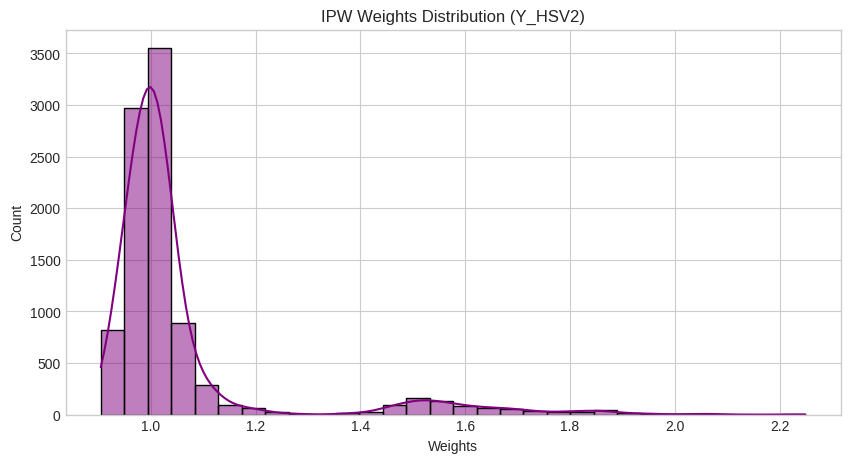

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("1. IPW Distribution")
    sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_HSV2')

IPW Love Plot


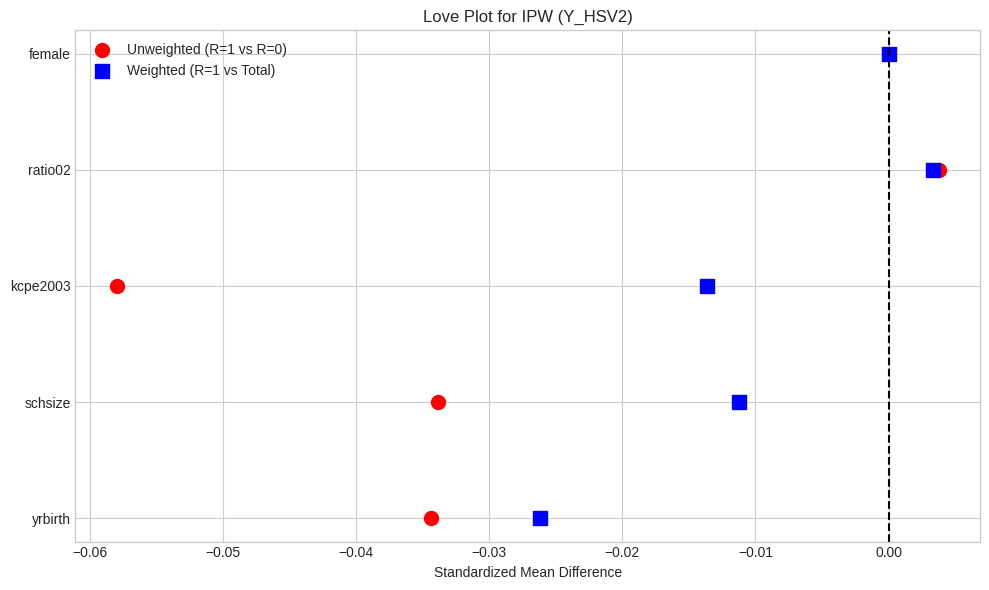

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("IPW Love Plot")
    plot_love_plot(sub, 'Y_HSV2')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("2. Joint Wald Test")
    wald_pval = calc_joint_wald(sub, sub_X_Lasso, 'Y_HSV2')

2. Joint Wald Test
  D_S: ATE = -0.0060, SE = 0.0106, P = 0.5739
  D_H: ATE = -0.0160, SE = 0.0105, P = 0.1281
  D_SH: ATE = -0.0473, SE = 0.0100, P = 0.0000
  Additivity Test (Wald): P-Value = 0.0786


##### D_S Analysis for Y_HSV2

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_HSV2', 'D_S')
    final_results['Y_HSV2_Female']['D_S'] = {'irm_coef': dml_irm_D_S.coef[0], 'irm_se': dml_irm_D_S.se[0], 'irm_p': dml_irm_D_S.pval[0]}


DML & WLS for D_S


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
D_S,0.011435,0.011141,1.026433,0.304687,-0.0104,0.033271


Effect D_S: 0.0101 (SE: 0.0154, P-val: 0.5114)


In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_HSV2', 'D_S')

Heterogeneity BLP Test


KeyboardInterrupt: 

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_S, 'Y_HSV2', 'D_S')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_S = plot_feat_importance(rf_cate_D_S, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_HSV2', 'D_S')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_HSV2', 'D_S')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_S, X_h_D_S, 'Y_HSV2', 'D_S')

##### D_H Analysis for Y_HSV2

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_HSV2', 'D_H')
    final_results['Y_HSV2_Female']['D_H'] = {'irm_coef': dml_irm_D_H.coef[0], 'irm_se': dml_irm_D_H.se[0], 'irm_p': dml_irm_D_H.pval[0]}


In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_HSV2', 'D_H')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_H, 'Y_HSV2', 'D_H')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_H = plot_feat_importance(rf_cate_D_H, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_HSV2', 'D_H')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_HSV2', 'D_H')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_H, X_h_D_H, 'Y_HSV2', 'D_H')

##### D_SH Analysis for Y_HSV2

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_HSV2', 'D_SH')
    final_results['Y_HSV2_Female']['D_SH'] = {'irm_coef': dml_irm_D_SH.coef[0], 'irm_se': dml_irm_D_SH.se[0], 'irm_p': dml_irm_D_SH.pval[0]}


In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_HSV2', 'D_SH')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_SH, 'Y_HSV2', 'D_SH')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_SH = plot_feat_importance(rf_cate_D_SH, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_HSV2', 'D_SH')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_HSV2', 'D_SH')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_SH, X_h_D_SH, 'Y_HSV2', 'D_SH')

#### Reached 8th Grade (7 yr) (Female)

In [ ]:
sub = df[df['female'] == 1].copy()
if sub['Y_Reached_8th'].notna().sum() <= 50:
    print("Insufficient data for Y_Reached_8th (Female).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_Reached_8th_Female' not in final_results:
        final_results['Y_Reached_8th_Female'] = {}


In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("1. IPW Distribution")
    sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_Reached_8th')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("IPW Love Plot")
    plot_love_plot(sub, 'Y_Reached_8th')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("2. Joint Wald Test")
    wald_pval = calc_joint_wald(sub, sub_X_Lasso, 'Y_Reached_8th')

##### D_S Analysis for Y_Reached_8th

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Reached_8th', 'D_S')
    final_results['Y_Reached_8th_Female']['D_S'] = {'irm_coef': dml_irm_D_S.coef[0], 'irm_se': dml_irm_D_S.se[0], 'irm_p': dml_irm_D_S.pval[0]}


In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_Reached_8th', 'D_S')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_S, 'Y_Reached_8th', 'D_S')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_S = plot_feat_importance(rf_cate_D_S, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Reached_8th', 'D_S')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_Reached_8th', 'D_S')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_S, X_h_D_S, 'Y_Reached_8th', 'D_S')

##### D_H Analysis for Y_Reached_8th

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Reached_8th', 'D_H')
    final_results['Y_Reached_8th_Female']['D_H'] = {'irm_coef': dml_irm_D_H.coef[0], 'irm_se': dml_irm_D_H.se[0], 'irm_p': dml_irm_D_H.pval[0]}


In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_Reached_8th', 'D_H')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_H, 'Y_Reached_8th', 'D_H')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_H = plot_feat_importance(rf_cate_D_H, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Reached_8th', 'D_H')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_Reached_8th', 'D_H')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_H, X_h_D_H, 'Y_Reached_8th', 'D_H')

##### D_SH Analysis for Y_Reached_8th

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Reached_8th', 'D_SH')
    final_results['Y_Reached_8th_Female']['D_SH'] = {'irm_coef': dml_irm_D_SH.coef[0], 'irm_se': dml_irm_D_SH.se[0], 'irm_p': dml_irm_D_SH.pval[0]}


In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_Reached_8th', 'D_SH')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_SH, 'Y_Reached_8th', 'D_SH')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_SH = plot_feat_importance(rf_cate_D_SH, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Reached_8th', 'D_SH')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_Reached_8th', 'D_SH')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_SH, X_h_D_SH, 'Y_Reached_8th', 'D_SH')

#### Years of School Completed (7 yr) (Female)

In [ ]:
sub = df[df['female'] == 1].copy()
if sub['Y_Grades_Comp'].notna().sum() <= 50:
    print("Insufficient data for Y_Grades_Comp (Female).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_Grades_Comp_Female' not in final_results:
        final_results['Y_Grades_Comp_Female'] = {}


In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("1. IPW Distribution")
    sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_Grades_Comp')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("IPW Love Plot")
    plot_love_plot(sub, 'Y_Grades_Comp')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("2. Joint Wald Test")
    wald_pval = calc_joint_wald(sub, sub_X_Lasso, 'Y_Grades_Comp')

##### D_S Analysis for Y_Grades_Comp

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Grades_Comp', 'D_S')
    final_results['Y_Grades_Comp_Female']['D_S'] = {'irm_coef': dml_irm_D_S.coef[0], 'irm_se': dml_irm_D_S.se[0], 'irm_p': dml_irm_D_S.pval[0]}


In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_Grades_Comp', 'D_S')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_S, 'Y_Grades_Comp', 'D_S')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_S = plot_feat_importance(rf_cate_D_S, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Grades_Comp', 'D_S')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_Grades_Comp', 'D_S')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_S, X_h_D_S, 'Y_Grades_Comp', 'D_S')

##### D_H Analysis for Y_Grades_Comp

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Grades_Comp', 'D_H')
    final_results['Y_Grades_Comp_Female']['D_H'] = {'irm_coef': dml_irm_D_H.coef[0], 'irm_se': dml_irm_D_H.se[0], 'irm_p': dml_irm_D_H.pval[0]}


In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_Grades_Comp', 'D_H')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_H, 'Y_Grades_Comp', 'D_H')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_H = plot_feat_importance(rf_cate_D_H, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Grades_Comp', 'D_H')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_Grades_Comp', 'D_H')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_H, X_h_D_H, 'Y_Grades_Comp', 'D_H')

##### D_SH Analysis for Y_Grades_Comp

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Grades_Comp', 'D_SH')
    final_results['Y_Grades_Comp_Female']['D_SH'] = {'irm_coef': dml_irm_D_SH.coef[0], 'irm_se': dml_irm_D_SH.se[0], 'irm_p': dml_irm_D_SH.pval[0]}


In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_Grades_Comp', 'D_SH')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_SH, 'Y_Grades_Comp', 'D_SH')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_SH = plot_feat_importance(rf_cate_D_SH, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Grades_Comp', 'D_SH')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_Grades_Comp', 'D_SH')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_SH, X_h_D_SH, 'Y_Grades_Comp', 'D_SH')

### --- MALE SAMPLE ---

#### School Dropout (3 yr) (Male)

In [ ]:
sub = df[df['female'] == 0].copy()
if sub['Y_Drop_3yr'].notna().sum() <= 50:
    print("Insufficient data for Y_Drop_3yr (Male).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_Drop_3yr_Male' not in final_results:
        final_results['Y_Drop_3yr_Male'] = {}


In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("1. IPW Distribution")
    sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_Drop_3yr')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("IPW Love Plot")
    plot_love_plot(sub, 'Y_Drop_3yr')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("2. Joint Wald Test")
    wald_pval = calc_joint_wald(sub, sub_X_Lasso, 'Y_Drop_3yr')

##### D_S Analysis for Y_Drop_3yr

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Drop_3yr', 'D_S')
    final_results['Y_Drop_3yr_Male']['D_S'] = {'irm_coef': dml_irm_D_S.coef[0], 'irm_se': dml_irm_D_S.se[0], 'irm_p': dml_irm_D_S.pval[0]}


In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_Drop_3yr', 'D_S')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_S, 'Y_Drop_3yr', 'D_S')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_S = plot_feat_importance(rf_cate_D_S, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Drop_3yr', 'D_S')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_Drop_3yr', 'D_S')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_S, X_h_D_S, 'Y_Drop_3yr', 'D_S')

##### D_H Analysis for Y_Drop_3yr

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Drop_3yr', 'D_H')
    final_results['Y_Drop_3yr_Male']['D_H'] = {'irm_coef': dml_irm_D_H.coef[0], 'irm_se': dml_irm_D_H.se[0], 'irm_p': dml_irm_D_H.pval[0]}


In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_Drop_3yr', 'D_H')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_H, 'Y_Drop_3yr', 'D_H')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_H = plot_feat_importance(rf_cate_D_H, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Drop_3yr', 'D_H')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_Drop_3yr', 'D_H')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_H, X_h_D_H, 'Y_Drop_3yr', 'D_H')

##### D_SH Analysis for Y_Drop_3yr

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Drop_3yr', 'D_SH')
    final_results['Y_Drop_3yr_Male']['D_SH'] = {'irm_coef': dml_irm_D_SH.coef[0], 'irm_se': dml_irm_D_SH.se[0], 'irm_p': dml_irm_D_SH.pval[0]}


In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_Drop_3yr', 'D_SH')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_SH, 'Y_Drop_3yr', 'D_SH')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_SH = plot_feat_importance(rf_cate_D_SH, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Drop_3yr', 'D_SH')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_Drop_3yr', 'D_SH')

In [ ]:
if sub['Y_Drop_3yr'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_SH, X_h_D_SH, 'Y_Drop_3yr', 'D_SH')

#### School Dropout (5 yr) (Male)

In [ ]:
sub = df[df['female'] == 0].copy()
if sub['Y_Drop'].notna().sum() <= 50:
    print("Insufficient data for Y_Drop (Male).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_Drop_Male' not in final_results:
        final_results['Y_Drop_Male'] = {}


In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("1. IPW Distribution")
    sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_Drop')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("IPW Love Plot")
    plot_love_plot(sub, 'Y_Drop')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("2. Joint Wald Test")
    wald_pval = calc_joint_wald(sub, sub_X_Lasso, 'Y_Drop')

##### D_S Analysis for Y_Drop

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Drop', 'D_S')
    final_results['Y_Drop_Male']['D_S'] = {'irm_coef': dml_irm_D_S.coef[0], 'irm_se': dml_irm_D_S.se[0], 'irm_p': dml_irm_D_S.pval[0]}


In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_Drop', 'D_S')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_S, 'Y_Drop', 'D_S')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_S = plot_feat_importance(rf_cate_D_S, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Drop', 'D_S')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_Drop', 'D_S')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_S, X_h_D_S, 'Y_Drop', 'D_S')

##### D_H Analysis for Y_Drop

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Drop', 'D_H')
    final_results['Y_Drop_Male']['D_H'] = {'irm_coef': dml_irm_D_H.coef[0], 'irm_se': dml_irm_D_H.se[0], 'irm_p': dml_irm_D_H.pval[0]}


In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_Drop', 'D_H')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_H, 'Y_Drop', 'D_H')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_H = plot_feat_importance(rf_cate_D_H, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Drop', 'D_H')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_Drop', 'D_H')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_H, X_h_D_H, 'Y_Drop', 'D_H')

##### D_SH Analysis for Y_Drop

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Drop', 'D_SH')
    final_results['Y_Drop_Male']['D_SH'] = {'irm_coef': dml_irm_D_SH.coef[0], 'irm_se': dml_irm_D_SH.se[0], 'irm_p': dml_irm_D_SH.pval[0]}


In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_Drop', 'D_SH')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_SH, 'Y_Drop', 'D_SH')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_SH = plot_feat_importance(rf_cate_D_SH, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Drop', 'D_SH')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_Drop', 'D_SH')

In [ ]:
if sub['Y_Drop'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_SH, X_h_D_SH, 'Y_Drop', 'D_SH')

#### HSV2 Infection (7 yr) (Male)

In [ ]:
sub = df[df['female'] == 0].copy()
if sub['Y_HSV2'].notna().sum() <= 50:
    print("Insufficient data for Y_HSV2 (Male).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_HSV2_Male' not in final_results:
        final_results['Y_HSV2_Male'] = {}


In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("1. IPW Distribution")
    sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_HSV2')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("IPW Love Plot")
    plot_love_plot(sub, 'Y_HSV2')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("2. Joint Wald Test")
    wald_pval = calc_joint_wald(sub, sub_X_Lasso, 'Y_HSV2')

##### D_S Analysis for Y_HSV2

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_HSV2', 'D_S')
    final_results['Y_HSV2_Male']['D_S'] = {'irm_coef': dml_irm_D_S.coef[0], 'irm_se': dml_irm_D_S.se[0], 'irm_p': dml_irm_D_S.pval[0]}


In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_HSV2', 'D_S')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_S, 'Y_HSV2', 'D_S')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_S = plot_feat_importance(rf_cate_D_S, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_HSV2', 'D_S')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_HSV2', 'D_S')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_S, X_h_D_S, 'Y_HSV2', 'D_S')

##### D_H Analysis for Y_HSV2

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_HSV2', 'D_H')
    final_results['Y_HSV2_Male']['D_H'] = {'irm_coef': dml_irm_D_H.coef[0], 'irm_se': dml_irm_D_H.se[0], 'irm_p': dml_irm_D_H.pval[0]}


In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_HSV2', 'D_H')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_H, 'Y_HSV2', 'D_H')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_H = plot_feat_importance(rf_cate_D_H, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_HSV2', 'D_H')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_HSV2', 'D_H')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_H, X_h_D_H, 'Y_HSV2', 'D_H')

##### D_SH Analysis for Y_HSV2

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_HSV2', 'D_SH')
    final_results['Y_HSV2_Male']['D_SH'] = {'irm_coef': dml_irm_D_SH.coef[0], 'irm_se': dml_irm_D_SH.se[0], 'irm_p': dml_irm_D_SH.pval[0]}


In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_HSV2', 'D_SH')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_SH, 'Y_HSV2', 'D_SH')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_SH = plot_feat_importance(rf_cate_D_SH, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_HSV2', 'D_SH')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_HSV2', 'D_SH')

In [ ]:
if sub['Y_HSV2'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_SH, X_h_D_SH, 'Y_HSV2', 'D_SH')

#### Reached 8th Grade (7 yr) (Male)

In [ ]:
sub = df[df['female'] == 0].copy()
if sub['Y_Reached_8th'].notna().sum() <= 50:
    print("Insufficient data for Y_Reached_8th (Male).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_Reached_8th_Male' not in final_results:
        final_results['Y_Reached_8th_Male'] = {}


In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("1. IPW Distribution")
    sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_Reached_8th')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("IPW Love Plot")
    plot_love_plot(sub, 'Y_Reached_8th')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("2. Joint Wald Test")
    wald_pval = calc_joint_wald(sub, sub_X_Lasso, 'Y_Reached_8th')

##### D_S Analysis for Y_Reached_8th

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Reached_8th', 'D_S')
    final_results['Y_Reached_8th_Male']['D_S'] = {'irm_coef': dml_irm_D_S.coef[0], 'irm_se': dml_irm_D_S.se[0], 'irm_p': dml_irm_D_S.pval[0]}


In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_Reached_8th', 'D_S')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_S, 'Y_Reached_8th', 'D_S')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_S = plot_feat_importance(rf_cate_D_S, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Reached_8th', 'D_S')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_Reached_8th', 'D_S')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_S, X_h_D_S, 'Y_Reached_8th', 'D_S')

##### D_H Analysis for Y_Reached_8th

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Reached_8th', 'D_H')
    final_results['Y_Reached_8th_Male']['D_H'] = {'irm_coef': dml_irm_D_H.coef[0], 'irm_se': dml_irm_D_H.se[0], 'irm_p': dml_irm_D_H.pval[0]}


In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_Reached_8th', 'D_H')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_H, 'Y_Reached_8th', 'D_H')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_H = plot_feat_importance(rf_cate_D_H, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Reached_8th', 'D_H')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_Reached_8th', 'D_H')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_H, X_h_D_H, 'Y_Reached_8th', 'D_H')

##### D_SH Analysis for Y_Reached_8th

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Reached_8th', 'D_SH')
    final_results['Y_Reached_8th_Male']['D_SH'] = {'irm_coef': dml_irm_D_SH.coef[0], 'irm_se': dml_irm_D_SH.se[0], 'irm_p': dml_irm_D_SH.pval[0]}


In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_Reached_8th', 'D_SH')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_SH, 'Y_Reached_8th', 'D_SH')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_SH = plot_feat_importance(rf_cate_D_SH, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Reached_8th', 'D_SH')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_Reached_8th', 'D_SH')

In [ ]:
if sub['Y_Reached_8th'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_SH, X_h_D_SH, 'Y_Reached_8th', 'D_SH')

#### Years of School Completed (7 yr) (Male)

In [ ]:
sub = df[df['female'] == 0].copy()
if sub['Y_Grades_Comp'].notna().sum() <= 50:
    print("Insufficient data for Y_Grades_Comp (Male).")
else:
    sub_X_Tree = X_Tree.loc[sub.index]
    sub_X_Lasso = X_Lasso.loc[sub.index]
    if 'Y_Grades_Comp_Male' not in final_results:
        final_results['Y_Grades_Comp_Male'] = {}


In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("1. IPW Distribution")
    sub = calc_and_plot_ipw(sub, sub_X_Tree, 'Y_Grades_Comp')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("IPW Love Plot")
    plot_love_plot(sub, 'Y_Grades_Comp')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("2. Joint Wald Test")
    wald_pval = calc_joint_wald(sub, sub_X_Lasso, 'Y_Grades_Comp')

##### D_S Analysis for Y_Grades_Comp

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("DML & WLS for D_S")
    dml_irm_D_S, dr_score_D_S, dml_df_D_S = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Grades_Comp', 'D_S')
    final_results['Y_Grades_Comp_Male']['D_S'] = {'irm_coef': dml_irm_D_S.coef[0], 'irm_se': dml_irm_D_S.se[0], 'irm_p': dml_irm_D_S.pval[0]}


In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_S, X_h_D_S, cate_pred_D_S = calc_heterogeneity(dml_df_D_S, dr_score_D_S, sub, 'Y_Grades_Comp', 'D_S')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_S, 'Y_Grades_Comp', 'D_S')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_S = plot_feat_importance(rf_cate_D_S, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Grades_Comp', 'D_S')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_S, X_h_D_S, top_vars_D_S, 'Y_Grades_Comp', 'D_S')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_S, X_h_D_S, 'Y_Grades_Comp', 'D_S')

##### D_H Analysis for Y_Grades_Comp

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("DML & WLS for D_H")
    dml_irm_D_H, dr_score_D_H, dml_df_D_H = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Grades_Comp', 'D_H')
    final_results['Y_Grades_Comp_Male']['D_H'] = {'irm_coef': dml_irm_D_H.coef[0], 'irm_se': dml_irm_D_H.se[0], 'irm_p': dml_irm_D_H.pval[0]}


In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_H, X_h_D_H, cate_pred_D_H = calc_heterogeneity(dml_df_D_H, dr_score_D_H, sub, 'Y_Grades_Comp', 'D_H')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_H, 'Y_Grades_Comp', 'D_H')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_H = plot_feat_importance(rf_cate_D_H, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Grades_Comp', 'D_H')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_H, X_h_D_H, top_vars_D_H, 'Y_Grades_Comp', 'D_H')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_H, X_h_D_H, 'Y_Grades_Comp', 'D_H')

##### D_SH Analysis for Y_Grades_Comp

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("DML & WLS for D_SH")
    dml_irm_D_SH, dr_score_D_SH, dml_df_D_SH = calc_dml_and_wls(sub, sub_X_Tree, 'Y_Grades_Comp', 'D_SH')
    final_results['Y_Grades_Comp_Male']['D_SH'] = {'irm_coef': dml_irm_D_SH.coef[0], 'irm_se': dml_irm_D_SH.se[0], 'irm_p': dml_irm_D_SH.pval[0]}


In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Heterogeneity BLP Test")
    rf_cate_D_SH, X_h_D_SH, cate_pred_D_SH = calc_heterogeneity(dml_df_D_SH, dr_score_D_SH, sub, 'Y_Grades_Comp', 'D_SH')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("CATE Distribution")
    plot_cate_dist(cate_pred_D_SH, 'Y_Grades_Comp', 'D_SH')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Feature Importance")
    top_vars_D_SH = plot_feat_importance(rf_cate_D_SH, ['yrbirth', 'schsize', 'kcpe2003', 'ratio02', 'female'], 'Y_Grades_Comp', 'D_SH')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Partial Dependence Plots (PDP)")
    plot_pdp(rf_cate_D_SH, X_h_D_SH, top_vars_D_SH, 'Y_Grades_Comp', 'D_SH')

In [ ]:
if sub['Y_Grades_Comp'].notna().sum() > 50:
    print("Policy Tree")
    plot_policy_tree(dr_score_D_SH, X_h_D_SH, 'Y_Grades_Comp', 'D_SH')

## 5. Final Puzzle of Duflo (Gender Comparison)

In [ ]:
for gender_name in ['Female', 'Male']:
    out_plot_keys = [k for k in final_results.keys() if k.endswith(f"_{gender_name}")]

    if out_plot_keys:
        labels = [k.replace(f'_{gender_name}', '').replace('Y_', '') for k in out_plot_keys]

        s_pts = [final_results[k]['D_S']['irm_coef'] for k in out_plot_keys]
        s_err = [final_results[k]['D_S']['irm_se'] * 1.96 for k in out_plot_keys]
        h_pts = [final_results[k]['D_H']['irm_coef'] for k in out_plot_keys]
        h_err = [final_results[k]['D_H']['irm_se'] * 1.96 for k in out_plot_keys]
        sh_pts = [final_results[k]['D_SH']['irm_coef'] for k in out_plot_keys]
        sh_err = [final_results[k]['D_SH']['irm_se'] * 1.96 for k in out_plot_keys]

        x = np.arange(len(labels))
        width = 0.25

        fig, ax = plt.subplots(figsize=(16, 7))
        ax.bar(x - width, s_pts, width, yerr=s_err, label='D_S (Subsidy)', color='skyblue', capsize=5)
        ax.bar(x, h_pts, width, yerr=h_err, label='D_H (HIV Edu)', color='lightgreen', capsize=5)
        ax.bar(x + width, sh_pts, width, yerr=sh_err, label='D_SH (Subsidy + HIV)', color='darkred', capsize=5)

        ax.set_ylabel('DoubleML Lasso Coefficient')
        ax.set_title(f"Duflo's Puzzle: Treatment Effects ({gender_name} Sample)")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45)
        ax.axhline(0, color='black', linestyle='-')
        ax.legend()
        plt.tight_layout()
        plt.show()
